<a href="https://colab.research.google.com/github/SMM303/Displacement-Analysis-/blob/main/WB_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║     WORLD BANK WDI — COMPLETE DATA PIPELINE  (API VERSION)                 ║
# ║     No ZIP downloads. No API key. No registration required.                ║
# ║     Data pulled live from the World Bank Open Data API.                    ║
# ║                                                                             ║
# ║     Author : Nabil Mansour  |  May 2026                                    ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
# WHAT THIS SCRIPT DOES — PLAIN ENGLISH
# ──────────────────────────────────────
# 1.  Installs the World Bank API library (wbgapi) and all analysis tools.
# 2.  Downloads 15 key development indicators for ALL countries, 2000–2023,
#     directly from the World Bank API — no file downloads needed.
# 3.  Merges all indicators into one clean master table and saves it as CSV.
# 4.  Cleans the data (removes duplicates, handles missing values, flags outliers).
# 5.  Runs Feature Analysis   — which variables matter most and why.
# 6.  Runs Exploratory Analysis — distributions, trends, maps, regional comparisons.
# 7.  Runs Relationship Analysis — which indicators are linked to each other.
# 8.  Trains a Random Forest   — predicts Life Expectancy from other indicators.
# 9.  Runs K-Means Clustering  — groups countries by development profile.
# 10. Trains Logistic Regression — classifies countries as high/low development.
# 11. Runs PCA (bonus)         — finds the hidden structure in the data.
# 12. Writes a full narrative insights report automatically.
# 13. Saves all charts and tables to a folder called  wdi_outputs/
#
# HOW TO RUN
# ──────────
# 1. Go to  https://colab.research.google.com
# 2. Create a new notebook
# 3. Paste this entire script into ONE cell
# 4. Click the Play (▶) button
# 5. Wait ~10 minutes — all outputs appear automatically
# ══════════════════════════════════════════════════════════════════════════════




In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1 — INSTALL LIBRARIES
# ══════════════════════════════════════════════════════════════════════════════
# This section installs everything the script needs.
# You do NOT need to do anything — it runs automatically.

print("=" * 70)
print("  STEP 1 of 13 — Installing required libraries ...")
print("=" * 70)

import subprocess, sys

# List of libraries to install
LIBRARIES = ["wbgapi", "shap", "plotly", "kaleido", "scikit-learn"]

for lib in LIBRARIES:
    subprocess.check_call([sys.executable, "-m", "pip", "install", lib, "-q"])
    print(f"  ✅  {lib} installed")

# ── Now import everything ─────────────────────────────────────────────────────
import warnings, gc, os
from pathlib import Path
from datetime import datetime

import numpy        as np
import pandas       as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn      as sns
import plotly.express as px
import wbgapi       as wb
import shap

from scipy import stats

from sklearn.ensemble        import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model    import LogisticRegression
from sklearn.cluster         import KMeans
from sklearn.decomposition   import PCA
from sklearn.preprocessing   import StandardScaler
from sklearn.impute          import SimpleImputer
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics         import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, roc_curve, classification_report,
    ConfusionMatrixDisplay, silhouette_score
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'font.family': 'DejaVu Sans'})

# ── Create output folders ─────────────────────────────────────────────────────
OUT  = Path("wdi_outputs")
FIGS = OUT / "figures"
OUT.mkdir(exist_ok=True)
FIGS.mkdir(exist_ok=True)

def save_fig(filename):
    """Save the current matplotlib figure to the figures folder."""
    plt.savefig(FIGS / filename, bbox_inches='tight', dpi=130)
    print(f"   💾  Chart saved → figures/{filename}")

print("\n✅  SECTION 1 COMPLETE — All libraries ready.\n")




  STEP 1 of 13 — Installing required libraries ...
  ✅  wbgapi installed
  ✅  shap installed
  ✅  plotly installed
  ✅  kaleido installed
  ✅  scikit-learn installed

✅  SECTION 1 COMPLETE — All libraries ready.



In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — DOWNLOAD DATA FROM WORLD BANK API
# ══════════════════════════════════════════════════════════════════════════════
# The World Bank API is FREE and requires NO api key, NO login, NO registration.
# The wbgapi library handles all the web requests for us automatically.
#
# We download 15 indicators for all countries from 2000 to 2023.
# Each indicator has a CODE (e.g. NY.GDP.PCAP.CD) and a HUMAN NAME.

print("=" * 70)
print("  STEP 2 of 13 — Downloading data from World Bank API ...")
print("  (No API key needed — this is a free, open data service)")
print("=" * 70)

# ── Define which indicators to download ──────────────────────────────────────
# Left side  = World Bank indicator code (do not change these)
# Right side = Human-readable column name (you can rename these)

INDICATORS = {
    "NY.GDP.PCAP.CD"    : "GDP_per_capita_USD",        # Income level
    "SP.DYN.LE00.IN"    : "Life_Expectancy_years",     # Health outcome
    "SH.DYN.MORT"       : "Child_Mortality_per1000",   # Child health
    "EG.ELC.ACCS.ZS"    : "Electricity_Access_pct",    # Infrastructure
    "IT.NET.USER.ZS"    : "Internet_Users_pct",        # Digital access
    "SE.ADT.LITR.ZS"    : "Adult_Literacy_pct",        # Education
    "SE.PRM.ENRR"       : "Primary_Enrolment_pct",     # Education
    "SH.XPD.CHEX.GD.ZS" : "Health_Expenditure_pct_GDP",# Health investment
    "SI.POV.GINI"       : "GINI_Inequality_Index",     # Inequality
    "SP.POP.TOTL"       : "Population_total",          # Size
    "NE.EXP.GNFS.ZS"    : "Exports_pct_GDP",           # Trade
    "FP.CPI.TOTL.ZG"    : "Inflation_pct",             # Stability
    "SL.UEM.TOTL.ZS"    : "Unemployment_pct",          # Labour
    "EN.ATM.CO2E.PC"    : "CO2_Emissions_per_capita",  # Environment
    "AG.LND.ARBL.ZS"    : "Arable_Land_pct",           # Agriculture
}

YEAR_START = 2000
YEAR_END   = 2023

# ── Download each indicator from the API ─────────────────────────────────────
# wbgapi downloads data as a table where rows = countries, columns = years.
# We convert each one to a long list (country + year + value) then merge them.

all_frames = []

for code, human_name in INDICATORS.items():
    try:
        print(f"  ⬇  Downloading: {human_name}  ({code}) ...", end=' ')

        # This one line calls the World Bank API and returns a pandas DataFrame
        raw = wb.data.DataFrame(
            series   = code,                          # which indicator
            economy  = wb.region.members('WLD'),      # all world countries
            time     = range(YEAR_START, YEAR_END+1), # year range
            labels   = True                           # include country names
        )

        # The DataFrame has countries as rows and years as columns.
        # We reshape it so each row = one (country, year, value).
        raw = raw.reset_index()

        # Identify year columns (they look like "YR2000", "YR2001", etc.)
        year_cols = [c for c in raw.columns if str(c).startswith('YR') or
                     (str(c).isdigit() and len(str(c)) == 4)]

        # Identify the country code column
        id_col = 'economy' if 'economy' in raw.columns else raw.columns[0]

        raw_long = raw.melt(
            id_vars    = [id_col],
            value_vars = year_cols,
            var_name   = 'Year_raw',
            value_name = human_name
        )

        # Clean up the year column (remove "YR" prefix if present)
        raw_long['Year'] = raw_long['Year_raw'].astype(str).str.replace('YR','').astype(int)
        raw_long = raw_long.rename(columns={id_col: 'Country_Code'})
        raw_long = raw_long[['Country_Code', 'Year', human_name]]
        raw_long[human_name] = pd.to_numeric(raw_long[human_name], errors='coerce')

        all_frames.append(raw_long)
        n_valid = raw_long[human_name].notna().sum()
        print(f"✅  {n_valid:,} data points")

    except Exception as e:
        print(f"⚠️  Skipped ({e})")

# ── Merge all indicators into one master table ────────────────────────────────
print("\n  🔗 Merging all indicators into one table ...")

df = all_frames[0].copy()
for frame in all_frames[1:]:
    df = df.merge(frame, on=['Country_Code', 'Year'], how='outer')

# ── Add country metadata (region, income group, country name) ─────────────────
print("  🌍 Adding country metadata (region, income group) ...")
try:
    meta = wb.economy.DataFrame()
    meta = meta.reset_index()[['id', 'name', 'region', 'incomeLevel']].rename(columns={
        'id'          : 'Country_Code',
        'name'        : 'Country_Name',
        'region'      : 'Region',
        'incomeLevel' : 'Income_Group'
    })
    df = df.merge(meta, on='Country_Code', how='left')
    print(f"  ✅  Country metadata merged")
except Exception as e:
    print(f"  ⚠️  Could not load metadata: {e}")

# ── Remove aggregates (keep only actual countries, not "World" or "Europe") ───
# The World Bank includes regional aggregates — we remove them to keep
# only real countries (they have a proper Region value)
if 'Region' in df.columns:
    AGGREGATE_REGIONS = ['Aggregates', 'NA', '']
    df = df[~df['Region'].isin(AGGREGATE_REGIONS) & df['Region'].notna()]

print(f"\n  📊 Master dataset dimensions:")
print(f"     Rows (country × year records) : {len(df):,}")
print(f"     Columns                       : {df.shape[1]}")
print(f"     Countries                     : {df['Country_Code'].nunique()}")
print(f"     Years covered                 : {df['Year'].min()} – {df['Year'].max()}")
print(f"     Indicators                    : {len(INDICATORS)}")

# ── Save master CSV ───────────────────────────────────────────────────────────
MASTER_PATH = OUT / "WDI_MASTER_FROM_API.csv"
df.to_csv(MASTER_PATH, index=False)
print(f"\n  💾  Master file saved → WDI_MASTER_FROM_API.csv")
print(f"      Size: {MASTER_PATH.stat().st_size / 1e6:.1f} MB")

print("\n✅  SECTION 2 COMPLETE — Data downloaded and merged.\n")




  STEP 2 of 13 — Downloading data from World Bank API ...
  (No API key needed — this is a free, open data service)
  ⬇  Downloading: GDP_per_capita_USD  (NY.GDP.PCAP.CD) ... ✅  5,041 data points
  ⬇  Downloading: Life_Expectancy_years  (SP.DYN.LE00.IN) ... ✅  5,208 data points
  ⬇  Downloading: Child_Mortality_per1000  (SH.DYN.MORT) ... ✅  4,704 data points
  ⬇  Downloading: Electricity_Access_pct  (EG.ELC.ACCS.ZS) ... ✅  5,135 data points
  ⬇  Downloading: Internet_Users_pct  (IT.NET.USER.ZS) ... ✅  4,708 data points
  ⬇  Downloading: Adult_Literacy_pct  (SE.ADT.LITR.ZS) ... ✅  892 data points
  ⬇  Downloading: Primary_Enrolment_pct  (SE.PRM.ENRR) ... ✅  3,989 data points
  ⬇  Downloading: Health_Expenditure_pct_GDP  (SH.XPD.CHEX.GD.ZS) ... ✅  4,540 data points
  ⬇  Downloading: GINI_Inequality_Index  (SI.POV.GINI) ... ✅  1,833 data points
  ⬇  Downloading: Population_total  (SP.POP.TOTL) ... ✅  5,208 data points
  ⬇  Downloading: Exports_pct_GDP  (NE.EXP.GNFS.ZS) ... ✅  4,252 data p

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3 — DATA CLEANING
# ══════════════════════════════════════════════════════════════════════════════
# We clean the data before analysis:
# - Remove duplicate rows
# - Report how much data is missing per indicator
# - Flag extreme statistical outliers
# - Create a snapshot table for the most recent year with good coverage

print("=" * 70)
print("  STEP 3 of 13 — Cleaning the data ...")
print("=" * 70)

INDICATOR_COLS = list(INDICATORS.values())  # all the numeric indicator columns
# Filter INDICATOR_COLS to include only columns present in df
INDICATOR_COLS = [col for col in INDICATOR_COLS if col in df.columns]

# ── Remove exact duplicate rows ───────────────────────────────────────────────
before = len(df)
df.drop_duplicates(subset=['Country_Code', 'Year'], inplace=True)
print(f"  Duplicate rows removed : {before - len(df)}")

# ── Missing data summary ──────────────────────────────────────────────────────
missing_pct = df[INDICATOR_COLS].isna().mean() * 100
missing_summary = pd.DataFrame({
    'Indicator'  : INDICATOR_COLS,
    'Missing_%'  : missing_pct.round(1).values
}).sort_values('Missing_%')

print(f"\n  Missing data per indicator:")
for _, row in missing_summary.iterrows():
    bar   = "█" * int(row['Missing_%'] / 5)
    level = "🟢" if row['Missing_%'] < 20 else "🟡" if row['Missing_%'] < 40 else "🔴"
    print(f"  {level}  {row['Indicator']:40s}  {row['Missing_%']:5.1f}%  {bar}")

missing_summary.to_csv(OUT / "data_quality_missing.csv", index=False)

# ── Flag statistical outliers using IQR method ────────────────────────────────
# An outlier is a value more than 5× the interquartile range from the median.
# We flag them but do NOT delete them (they may be real extreme cases).
df['outlier_flag'] = False
for col in INDICATOR_COLS:
    if col not in df.columns: continue
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    flag = (df[col] < q1 - 5*iqr) | (df[col] > q3 + 5*iqr)
    df.loc[flag, 'outlier_flag'] = True

outlier_count = df['outlier_flag'].sum()
print(f"\n  Extreme outliers flagged : {outlier_count:,} rows "
      f"({outlier_count/len(df)*100:.2f}% of data)")

# ── Create a single-year snapshot (best recent year with good coverage) ────────
# We use 2021 because 2022/2023 often has more missing data for some indicators
SNAPSHOT_YEAR = 2021
df_snap = df[df['Year'] == SNAPSHOT_YEAR].copy()

# Keep only rows that have at least half the indicators filled in
MIN_INDICATORS = len(INDICATOR_COLS) // 2
df_snap = df_snap.dropna(subset=INDICATOR_COLS, thresh=MIN_INDICATORS)

print(f"\n  Single-year snapshot ({SNAPSHOT_YEAR}):")
print(f"     Countries with sufficient data : {len(df_snap)}")

df_snap.to_csv(OUT / f"WDI_snapshot_{SNAPSHOT_YEAR}.csv", index=False)

print("\n✅  SECTION 3 COMPLETE — Data is clean and ready.\n")


  STEP 3 of 13 — Cleaning the data ...
  Duplicate rows removed : 0

  Missing data per indicator:
  🟢  Life_Expectancy_years                       0.0%  
  🟢  Population_total                            0.0%  
  🟢  Electricity_Access_pct                      1.4%  
  🟢  GDP_per_capita_USD                          3.2%  
  🟢  Arable_Land_pct                             5.8%  █
  🟢  Internet_Users_pct                          9.6%  █
  🟢  Child_Mortality_per1000                     9.7%  █
  🟢  Health_Expenditure_pct_GDP                 12.8%  ██
  🟢  Unemployment_pct                           13.9%  ██
  🟢  Inflation_pct                              16.6%  ███
  🟢  Exports_pct_GDP                            18.4%  ███
  🟡  Primary_Enrolment_pct                      23.4%  ████
  🔴  GINI_Inequality_Index                      64.8%  ████████████
  🔴  Adult_Literacy_pct                         82.9%  ████████████████

  Extreme outliers flagged : 420 rows (8.06% of data)

  Single-year sn

  STEP 4 of 13 — Feature Analysis ...
  Feature statistics (sorted by variation across countries):
                 Indicator        Mean     Median      Std_Dev   CV  Skewness  Missing_pct  N_countries
          Population_total 38767994.62 7413100.00 145391469.79 3.75      8.54         0.00          203
             Inflation_pct        8.61       3.48        30.41 3.53      9.57        12.30          178
        GDP_per_capita_USD    18570.74    6315.31     29619.17 1.59      3.72         2.00          199
   Child_Mortality_per1000       26.48      15.25        28.60 1.08      1.95         4.40          194
           Arable_Land_pct       14.13      10.21        13.84 0.98      1.31         2.50          198
           Exports_pct_GDP       42.99      33.64        34.86 0.81      2.36        12.80          177
          Unemployment_pct        8.11       6.04         6.08 0.75      1.64         8.90          185
Health_Expenditure_pct_GDP        7.14       6.64         3.17 0.44  

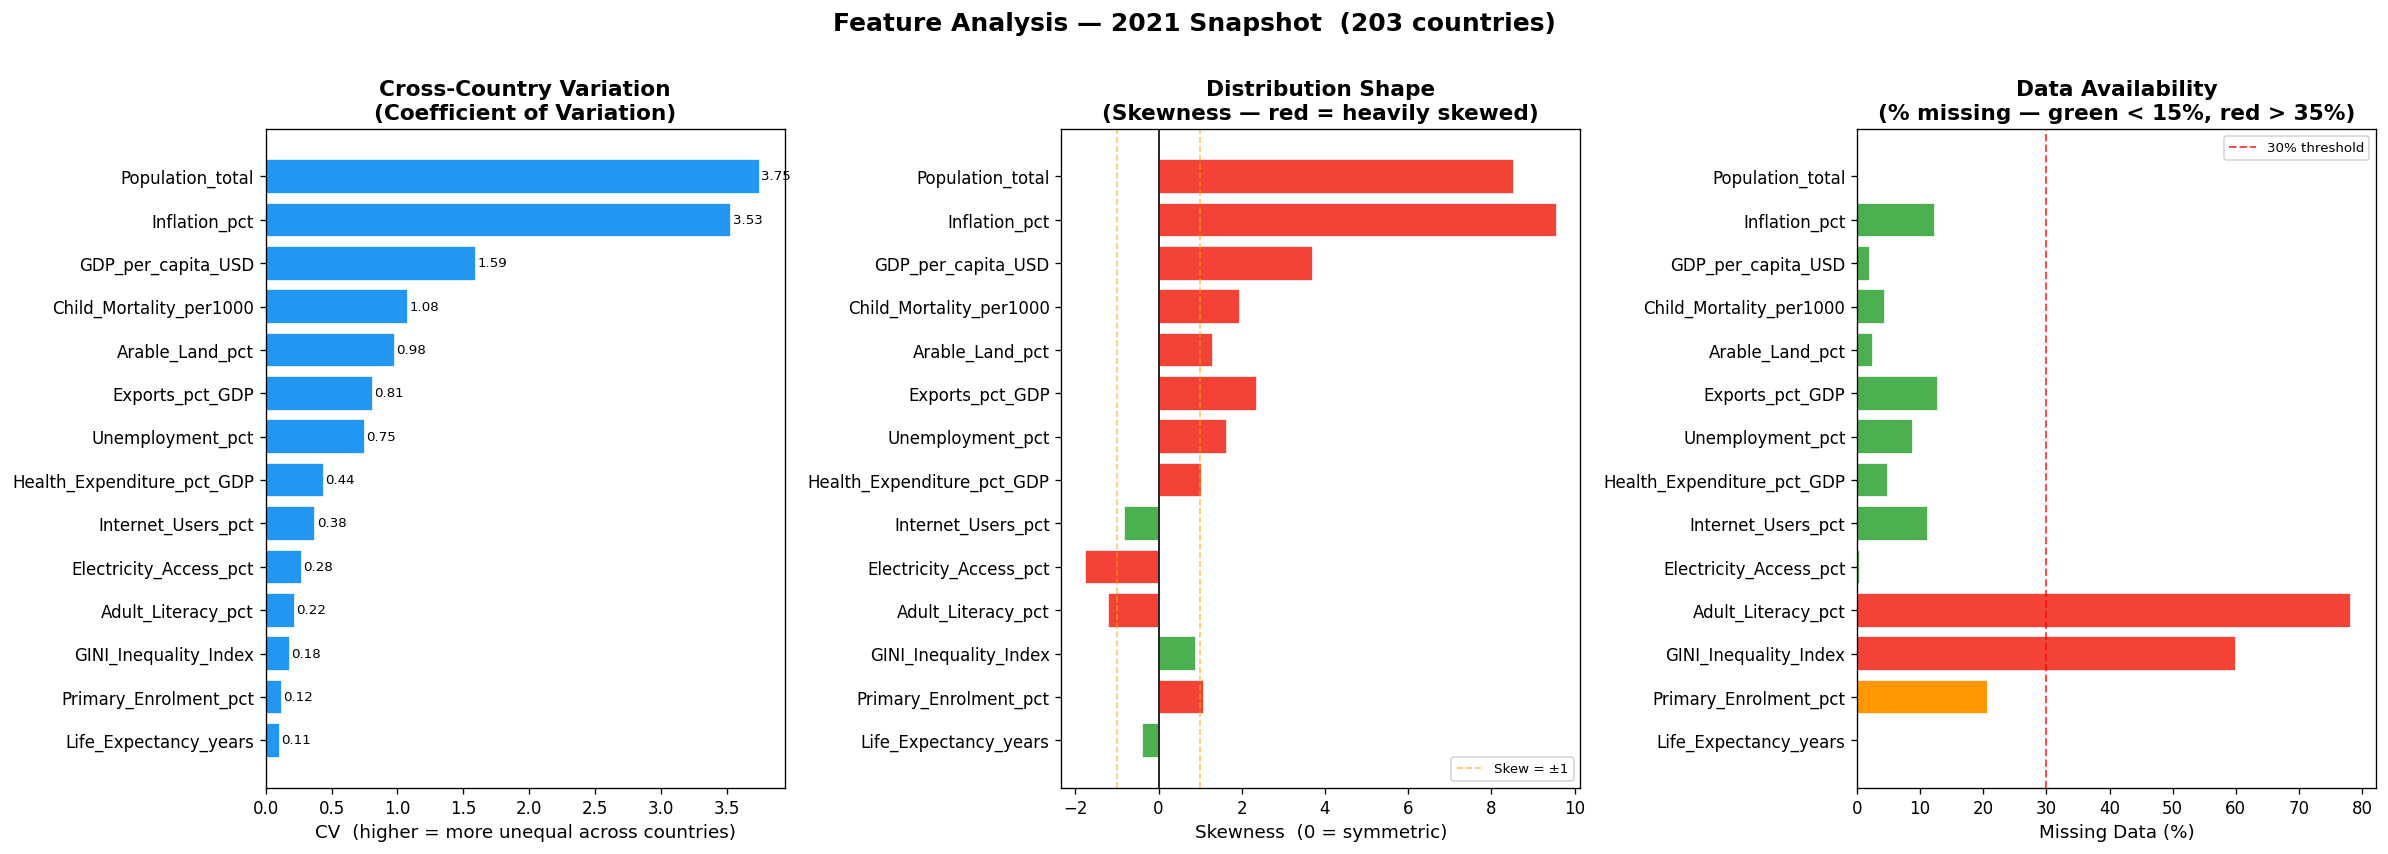

   💾  Chart saved → figures/S4b_correlation_matrix.png


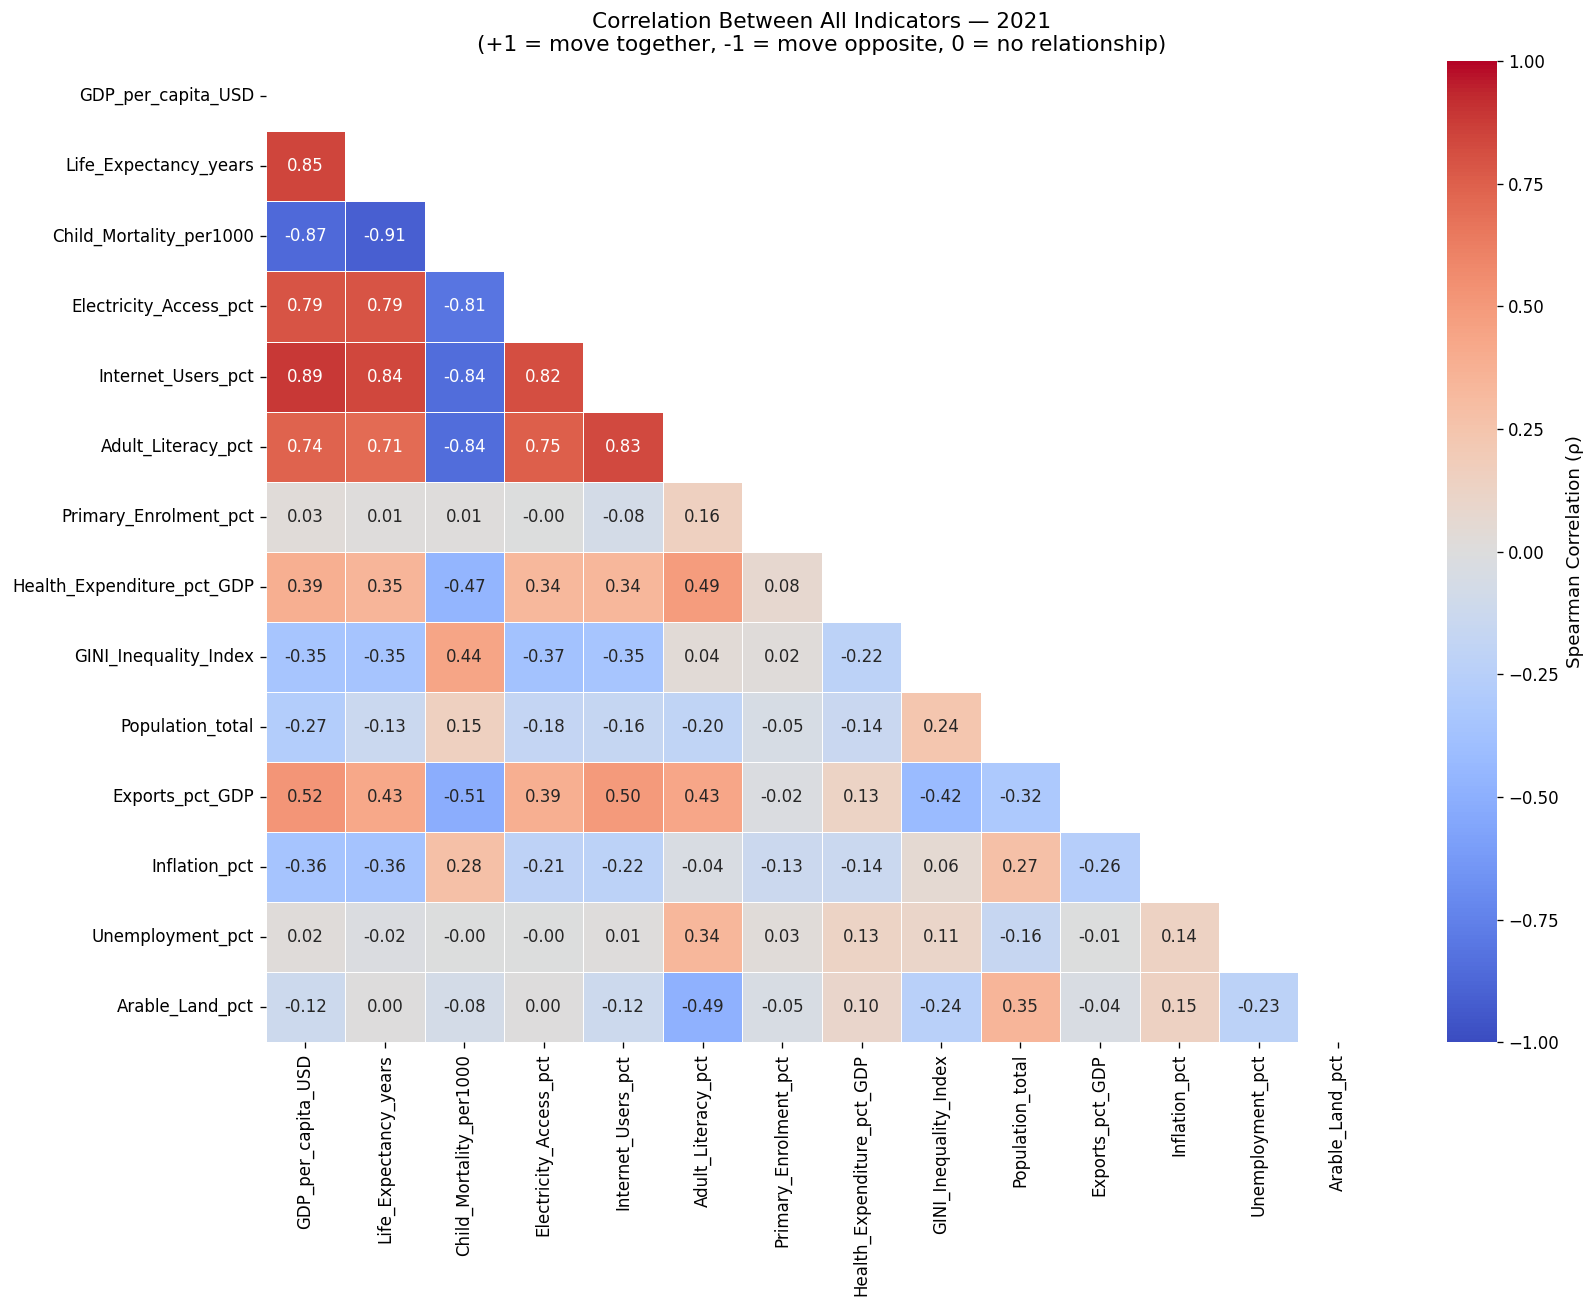


  Top 5 POSITIVE correlations (indicators that rise together):
     Internet_Users_pct                  ↔ GDP_per_capita_USD                   ρ = +0.888
     Life_Expectancy_years               ↔ GDP_per_capita_USD                   ρ = +0.847
     Internet_Users_pct                  ↔ Life_Expectancy_years                ρ = +0.838
     Adult_Literacy_pct                  ↔ Internet_Users_pct                   ρ = +0.833
     Internet_Users_pct                  ↔ Electricity_Access_pct               ρ = +0.819

  Top 5 NEGATIVE correlations (indicators that move opposite):
     Electricity_Access_pct              ↔ Child_Mortality_per1000              ρ = -0.811
     Internet_Users_pct                  ↔ Child_Mortality_per1000              ρ = -0.844
     Adult_Literacy_pct                  ↔ Child_Mortality_per1000              ρ = -0.844
     Child_Mortality_per1000             ↔ GDP_per_capita_USD                   ρ = -0.866
     Child_Mortality_per1000             ↔ Life_Expec

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4 — FEATURE ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════
# We examine each indicator to understand:
# - How much it varies across countries (Coefficient of Variation)
# - Whether it is symmetrically distributed or skewed
# - How strongly it correlates with other indicators

print("=" * 70)
print("  STEP 4 of 13 — Feature Analysis ...")
print("=" * 70)

# ── Compute descriptive statistics for each indicator ─────────────────────────
feat_stats = []
for col in INDICATOR_COLS:
    if col not in df_snap.columns: continue
    data = df_snap[col].dropna()
    if len(data) < 10: continue
    cv = data.std() / abs(data.mean()) if data.mean() != 0 else np.nan
    feat_stats.append({
        'Indicator'  : col,
        'Mean'       : round(data.mean(), 2),
        'Median'     : round(data.median(), 2),
        'Std_Dev'    : round(data.std(), 2),
        'CV'         : round(cv, 3),       # higher = more varied across countries
        'Skewness'   : round(data.skew(), 2),  # 0 = symmetric, >1 = right skew
        'Missing_pct': round(df_snap[col].isna().mean() * 100, 1),
        'N_countries': len(data),
    })

feat_df = pd.DataFrame(feat_stats).sort_values('CV', ascending=False)
feat_df.to_csv(OUT / "S4_feature_statistics.csv", index=False)

print("  Feature statistics (sorted by variation across countries):")
print(feat_df.to_string(index=False))

# ── Plot 1: Variation, Skewness, and Missing Data side by side ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Panel A: Coefficient of Variation (how different countries are from each other)
axes[0].barh(feat_df['Indicator'], feat_df['CV'], color='#2196F3', edgecolor='white')
axes[0].set_title('Cross-Country Variation\n(Coefficient of Variation)', fontweight='bold')
axes[0].set_xlabel('CV  (higher = more unequal across countries)')
axes[0].invert_yaxis()
for i, (val, name) in enumerate(zip(feat_df['CV'], feat_df['Indicator'])):
    axes[0].text(val + 0.01, i, f'{val:.2f}', va='center', fontsize=8)

# Panel B: Skewness (shape of distribution)
colors_skew = ['#F44336' if abs(s) > 1 else '#4CAF50' for s in feat_df['Skewness']]
axes[1].barh(feat_df['Indicator'], feat_df['Skewness'], color=colors_skew, edgecolor='white')
axes[1].axvline(0, color='black', lw=1)
axes[1].axvline(1,  color='orange', lw=1, linestyle='--', alpha=0.6, label='Skew = ±1')
axes[1].axvline(-1, color='orange', lw=1, linestyle='--', alpha=0.6)
axes[1].set_title('Distribution Shape\n(Skewness — red = heavily skewed)', fontweight='bold')
axes[1].set_xlabel('Skewness  (0 = symmetric)')
axes[1].legend(fontsize=8); axes[1].invert_yaxis()

# Panel C: Missing data per indicator
colors_miss = ['#F44336' if m > 35 else '#FF9800' if m > 15 else '#4CAF50'
               for m in feat_df['Missing_pct']]
axes[2].barh(feat_df['Indicator'], feat_df['Missing_pct'], color=colors_miss, edgecolor='white')
axes[2].axvline(30, color='red', lw=1.2, linestyle='--', alpha=0.7, label='30% threshold')
axes[2].set_title('Data Availability\n(% missing — green < 15%, red > 35%)', fontweight='bold')
axes[2].set_xlabel('Missing Data (%)')
axes[2].legend(fontsize=8); axes[2].invert_yaxis()

plt.suptitle(f'Feature Analysis — {SNAPSHOT_YEAR} Snapshot  ({len(df_snap)} countries)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
save_fig('S4a_feature_overview.png')
plt.show()

# ── Plot 2: Spearman Correlation Matrix ───────────────────────────────────────
available_cols = [c for c in INDICATOR_COLS if c in df_snap.columns]
corr = df_snap[available_cols].corr(method='spearman')

mask = np.triu(np.ones_like(corr, dtype=bool))   # hide upper triangle (it's a mirror)
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Spearman Correlation (ρ)'})
ax.set_title(f'Correlation Between All Indicators — {SNAPSHOT_YEAR}\n'
             '(+1 = move together, -1 = move opposite, 0 = no relationship)',
             fontsize=13)
plt.tight_layout()
save_fig('S4b_correlation_matrix.png')
plt.show()

# Print the 5 strongest positive and negative correlations
corr_flat = (corr.where(np.tril(np.ones_like(corr, dtype=bool), -1))
             .stack().reset_index()
             .rename(columns={'level_0': 'A', 'level_1': 'B', 0: 'rho'})
             .sort_values('rho', ascending=False))

print(f"\n  Top 5 POSITIVE correlations (indicators that rise together):")
for _, row in corr_flat.head(5).iterrows():
    print(f"     {row['A']:35s} ↔ {row['B']:35s}  ρ = {row['rho']:+.3f}")

print(f"\n  Top 5 NEGATIVE correlations (indicators that move opposite):")
for _, row in corr_flat.tail(5).iterrows():
    print(f"     {row['A']:35s} ↔ {row['B']:35s}  ρ = {row['rho']:+.3f}")

print("\n✅  SECTION 4 COMPLETE — Feature analysis done.\n")




  STEP 5 of 13 — Exploratory Data Analysis ...
   💾  Chart saved → figures/S5a_distributions.png


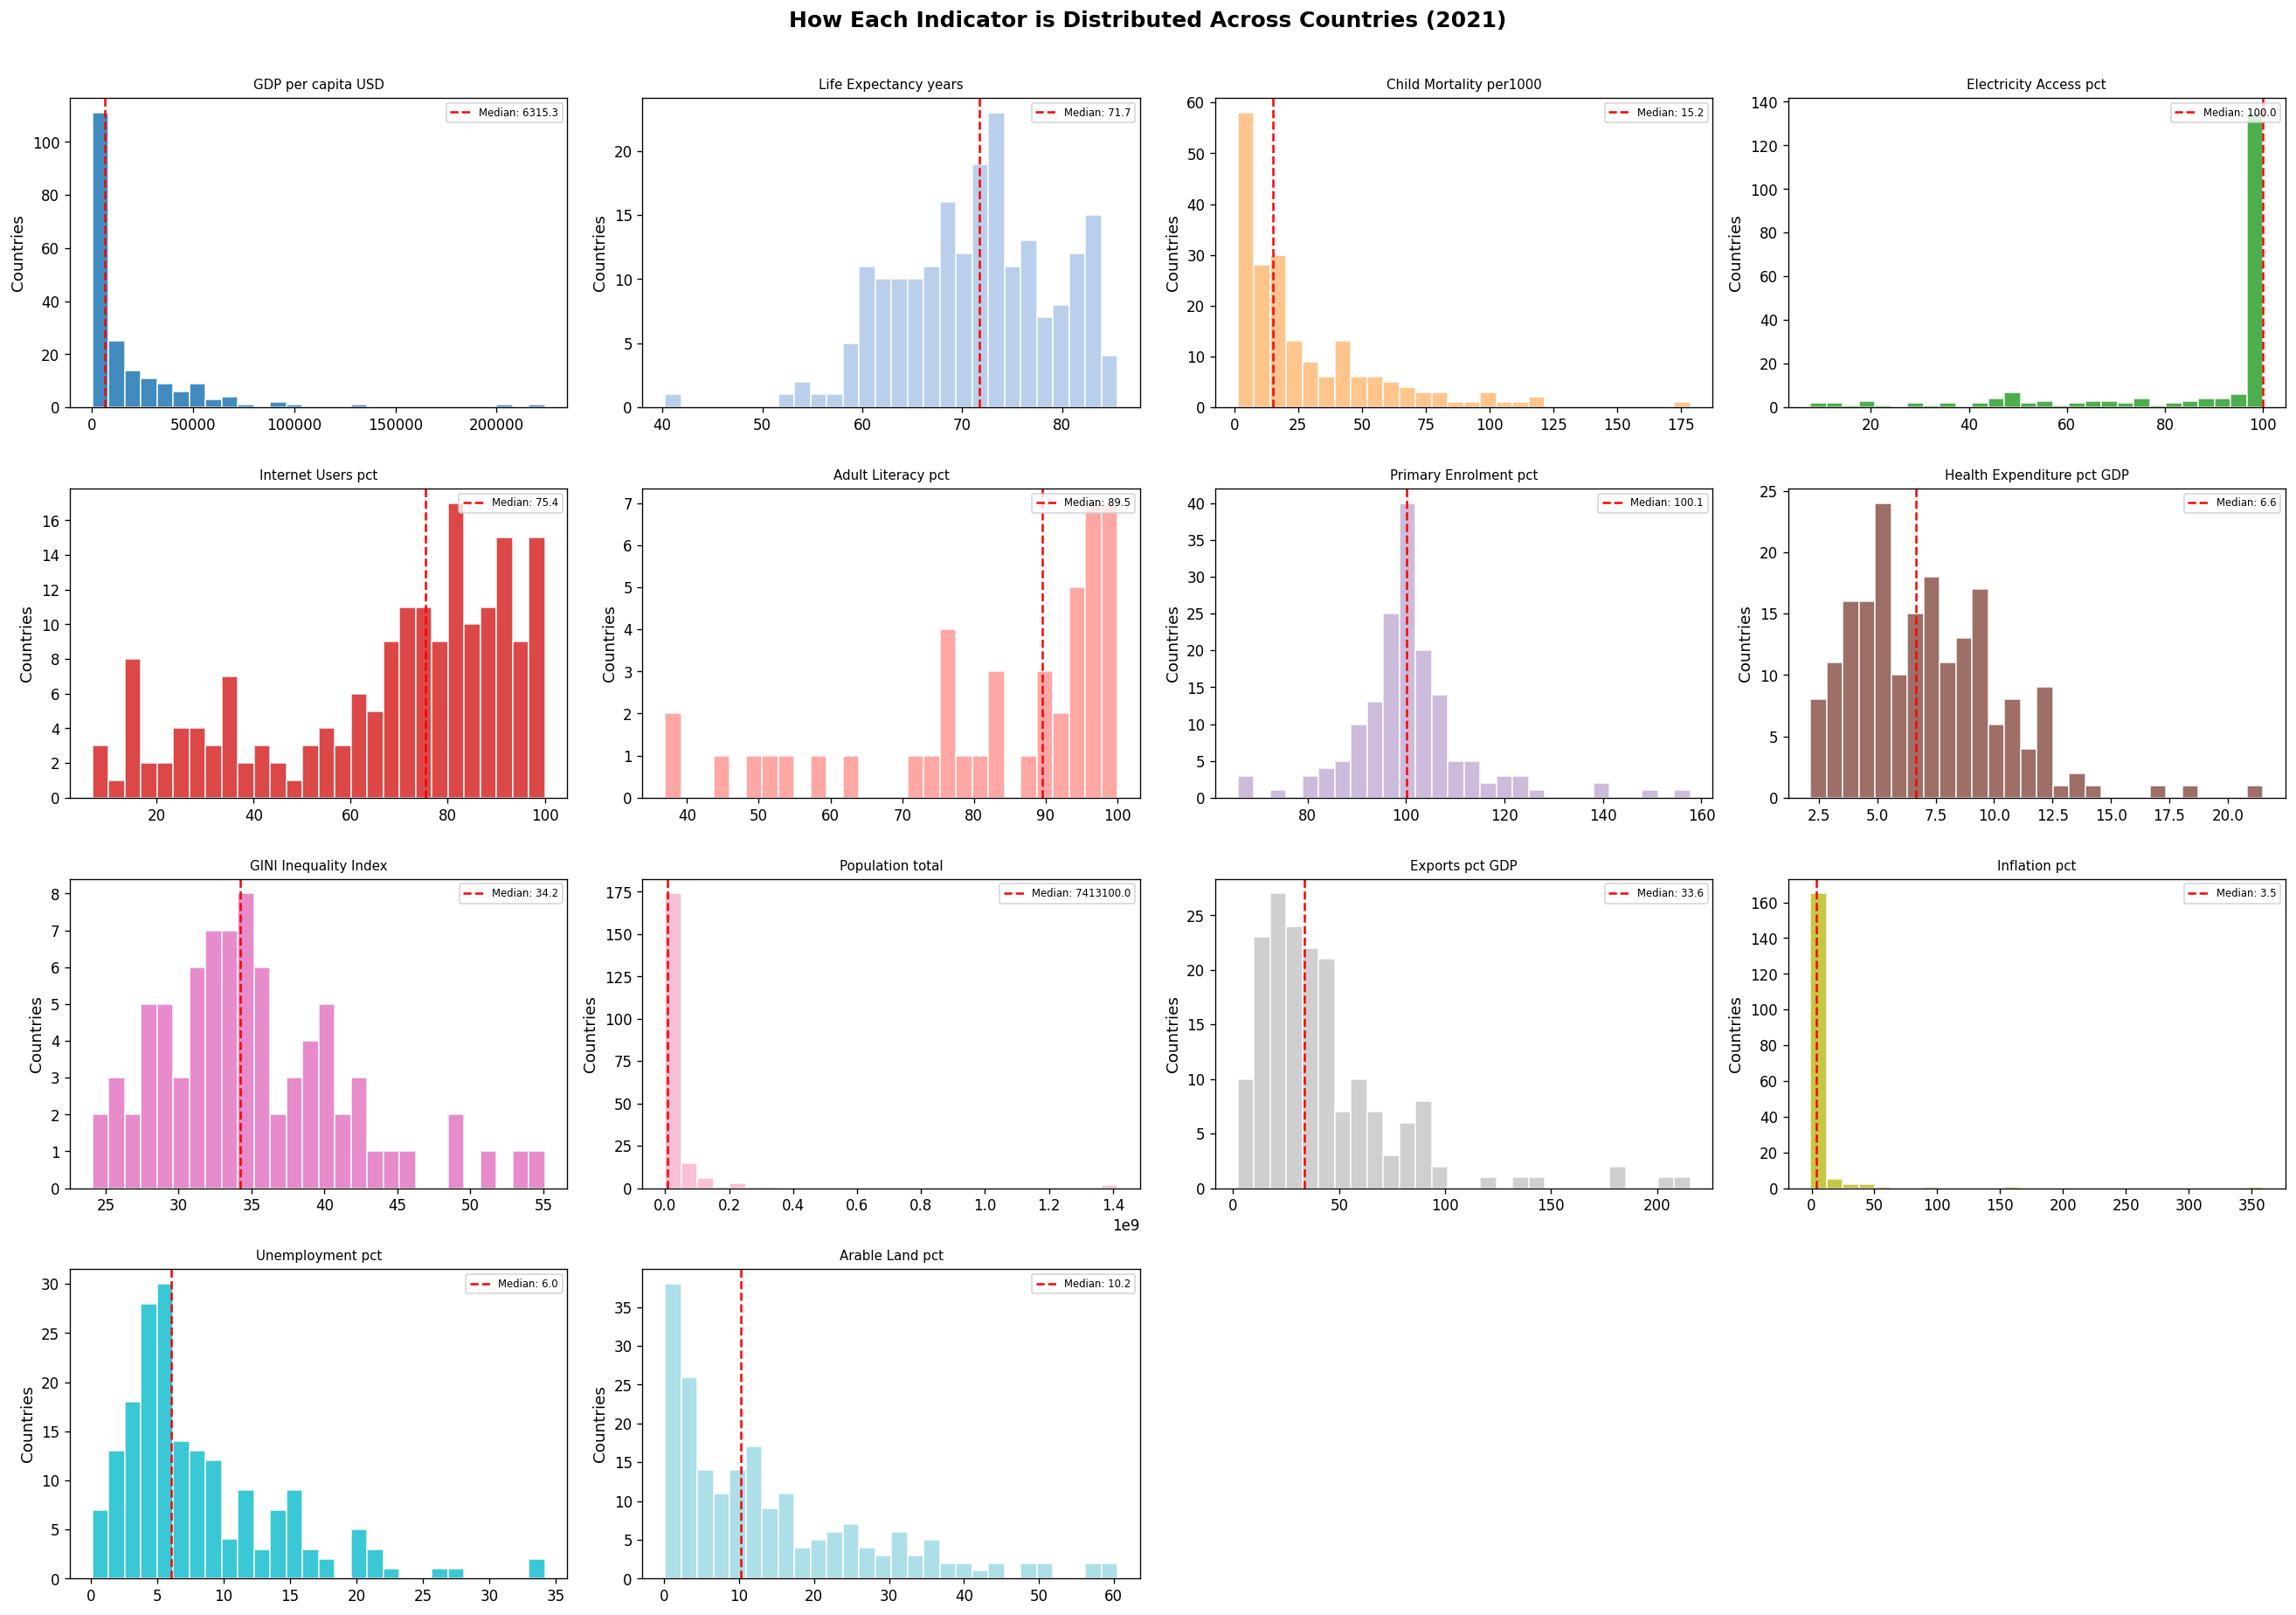

   💾  Chart saved → figures/S5b_income_group_boxes.png


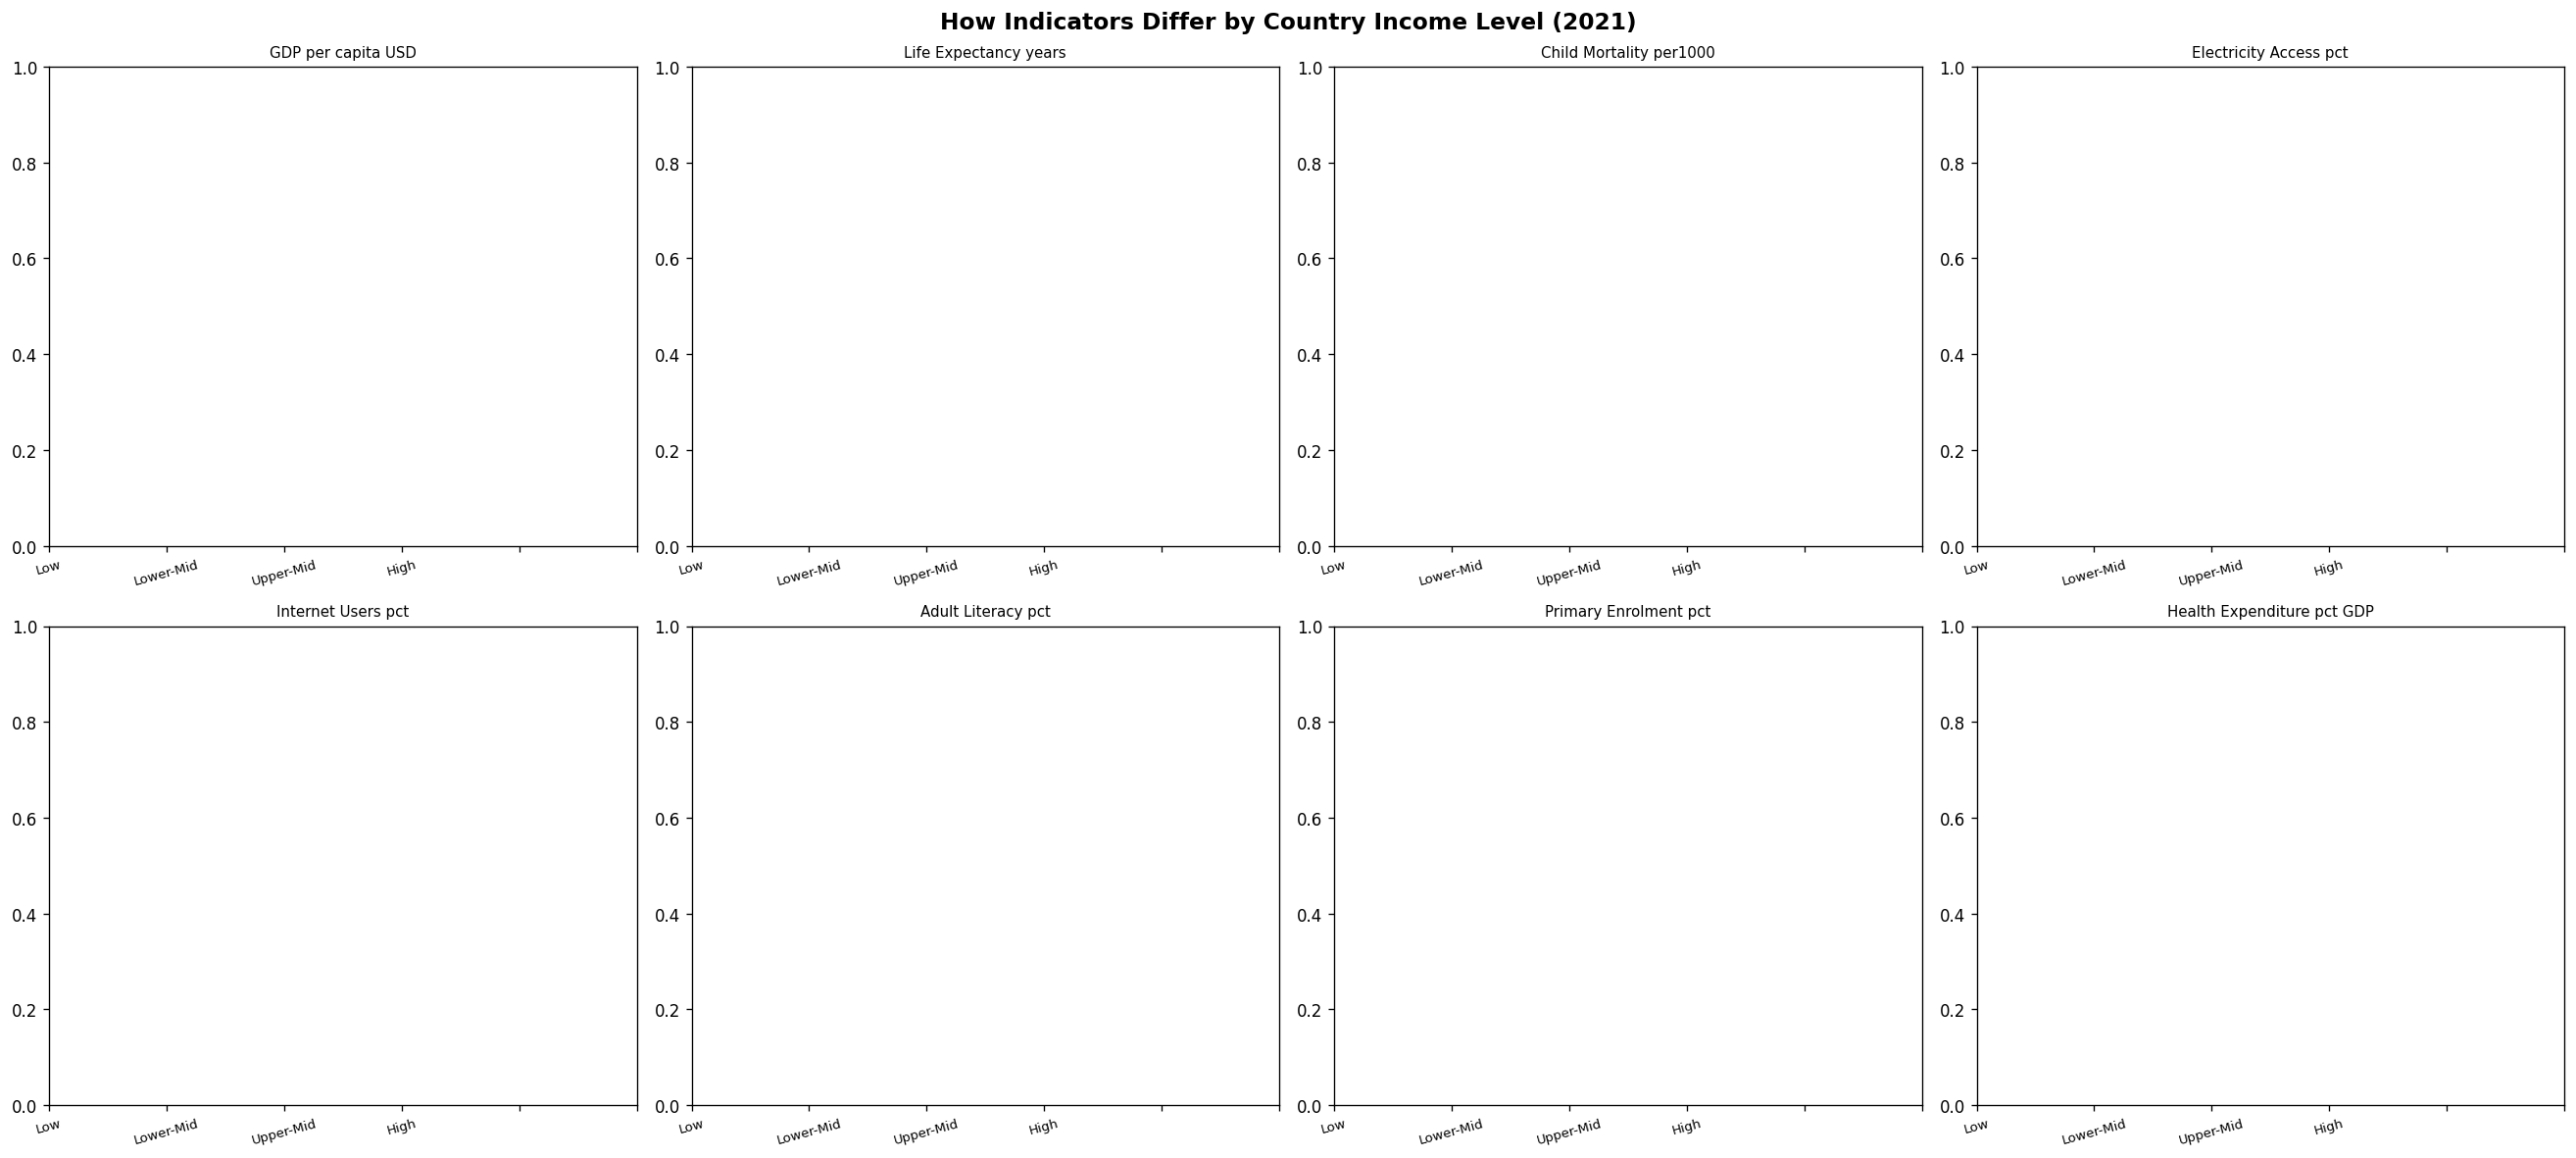

   💾  Chart saved → figures/S5c_global_trends.png


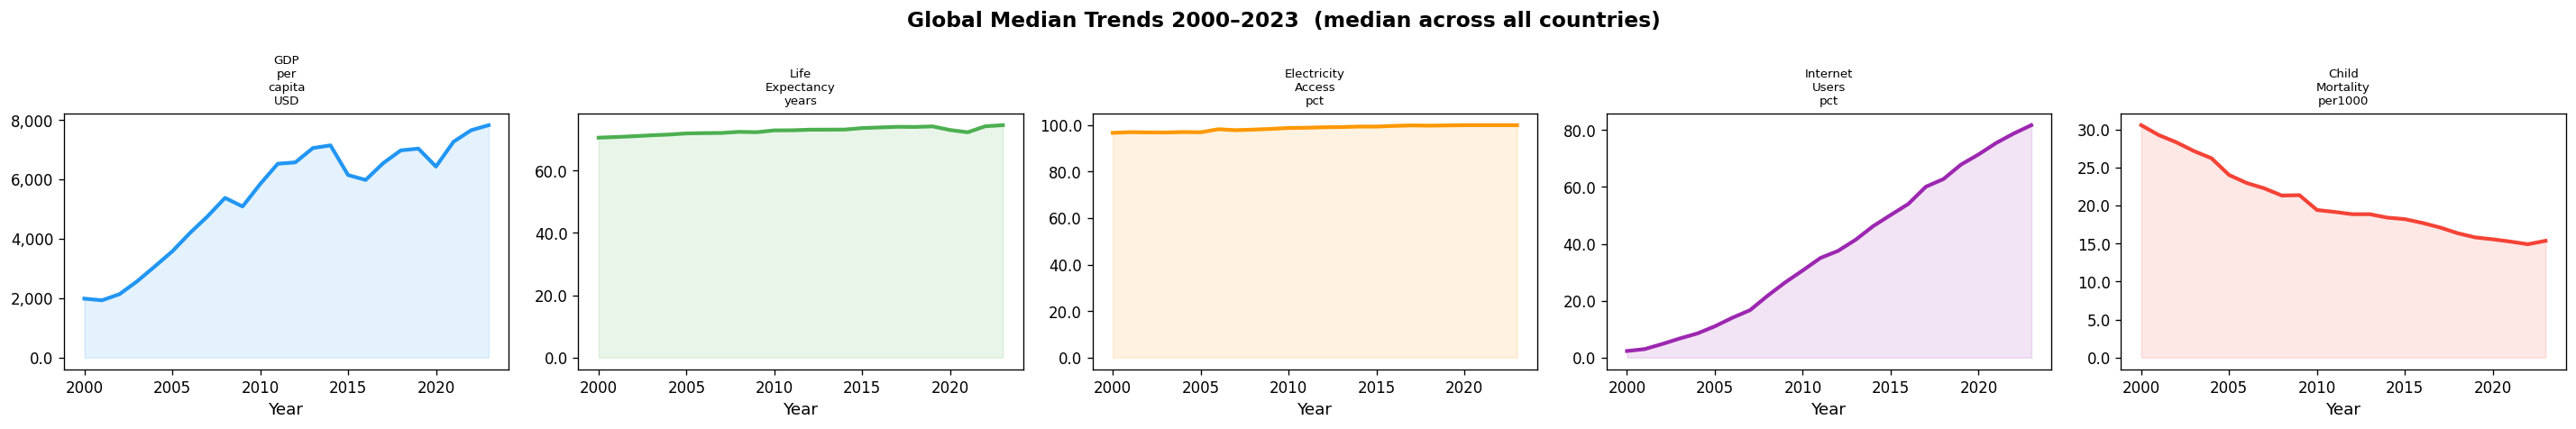

   💾  Chart saved → figures/S5d_regional_radar.png


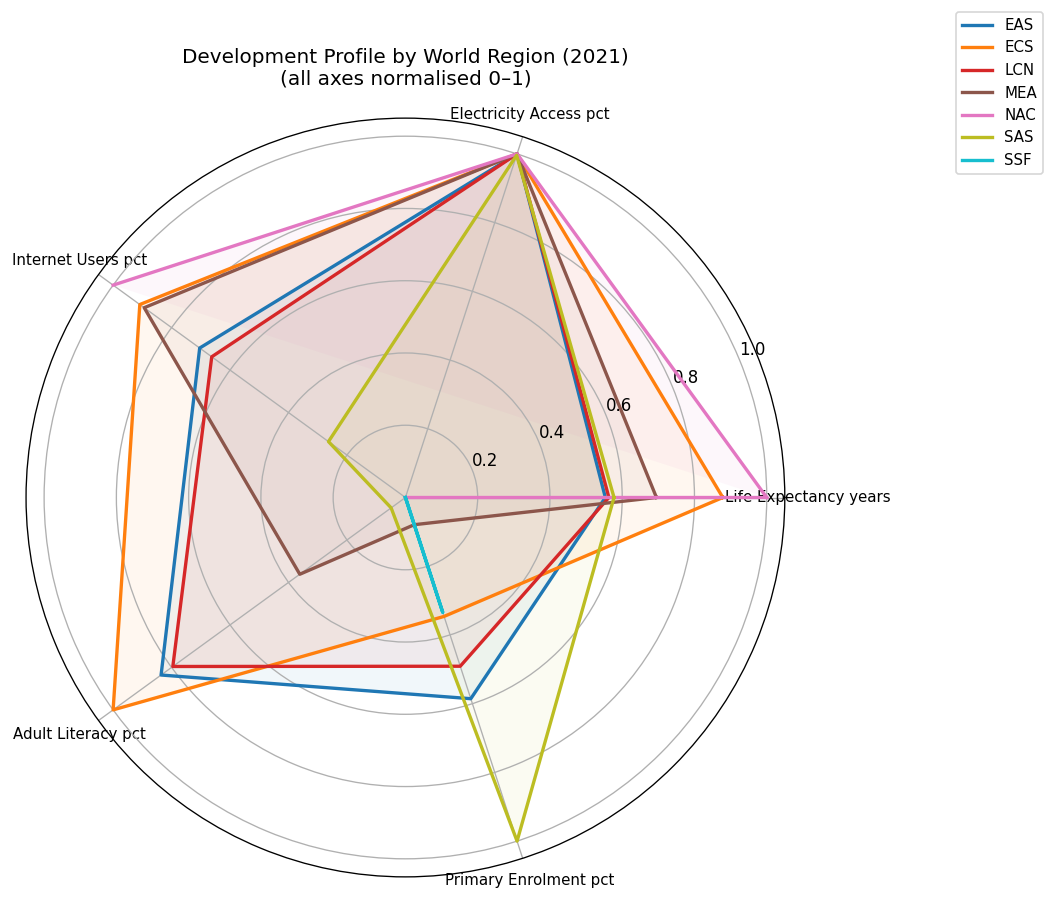

   💾  Chart saved → figures/S5e_gdp_vs_life_bubble.png


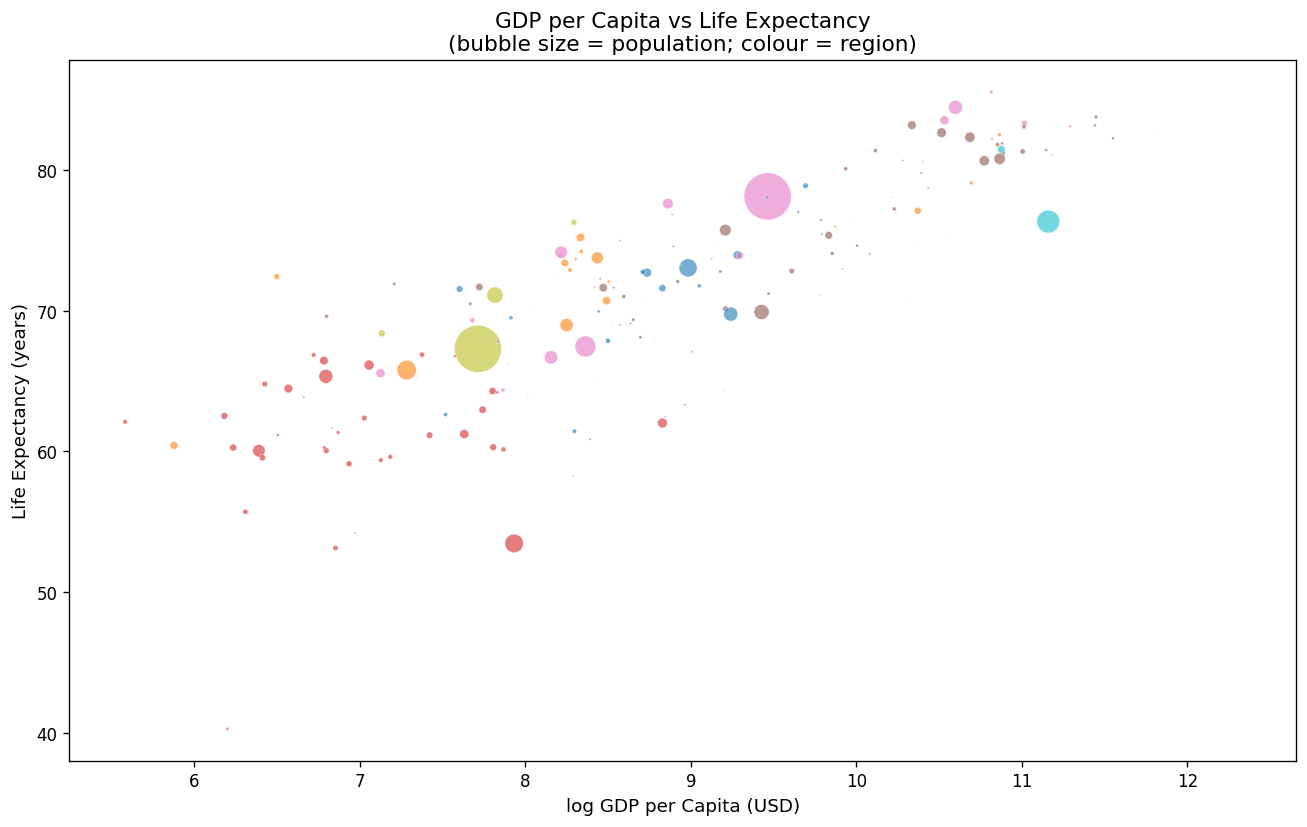


✅  SECTION 5 COMPLETE — Exploratory analysis charts saved.



In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5 — EXPLORATORY DATA ANALYSIS  (EDA)
# ══════════════════════════════════════════════════════════════════════════════
# We explore patterns in the data visually.

print("=" * 70)
print("  STEP 5 of 13 — Exploratory Data Analysis ...")
print("=" * 70)

# ── Plot 3: Distribution of every indicator (histogram grid) ──────────────────
# Each panel shows how the values are spread across all countries.
COLS_TO_PLOT = [c for c in INDICATOR_COLS if c in df_snap.columns]
n_cols = 4
n_rows = (len(COLS_TO_PLOT) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 3.8))
axes = axes.flatten()
palette = plt.cm.tab20(np.linspace(0, 1, len(COLS_TO_PLOT)))

for i, col in enumerate(COLS_TO_PLOT):
    data = df_snap[col].dropna()
    axes[i].hist(data, bins=28, color=palette[i], edgecolor='white', alpha=0.85)
    axes[i].axvline(data.median(), color='red', lw=1.5, linestyle='--',
                    label=f'Median: {data.median():.1f}')
    axes[i].set_title(col.replace('_', ' '), fontsize=9)
    axes[i].legend(fontsize=7, loc='upper right')
    axes[i].set_ylabel('Countries')

for j in range(i + 1, len(axes)): axes[j].set_visible(False)

fig.suptitle(f'How Each Indicator is Distributed Across Countries ({SNAPSHOT_YEAR})',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
save_fig('S5a_distributions.png')
plt.show()

# ── Plot 4: How countries differ by income group (box plots) ──────────────────
if 'Income_Group' in df_snap.columns:
    # Order income groups from poorest to richest
    income_order = ['Low income', 'Lower middle income',
                    'Upper middle income', 'High income']
    df_inc = df_snap[df_snap['Income_Group'].isin(income_order)].copy()

    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    axes = axes.flatten()
    key_cols = COLS_TO_PLOT[:8]

    for i, col in enumerate(key_cols):
        sns.boxplot(data=df_inc, x='Income_Group', y=col,
                    order=income_order, palette='Blues',
                    ax=axes[i], showfliers=False)
        axes[i].set_title(col.replace('_', ' '), fontsize=9)
        axes[i].set_xlabel('')
        axes[i].set_xticklabels(['Low', 'Lower-Mid', 'Upper-Mid', 'High'],
                                 rotation=15, fontsize=8)

    fig.suptitle(f'How Indicators Differ by Country Income Level ({SNAPSHOT_YEAR})',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_fig('S5b_income_group_boxes.png')
    plt.show()

# ── Plot 5: 20-year trend lines for 5 key indicators (global medians) ─────────
TREND_INDICATORS = {
    'GDP_per_capita_USD'       : '#2196F3',
    'Life_Expectancy_years'    : '#4CAF50',
    'Electricity_Access_pct'   : '#FF9800',
    'Internet_Users_pct'       : '#9C27B0',
    'Child_Mortality_per1000'  : '#F44336',
}

fig, axes = plt.subplots(1, 5, figsize=(24, 4))

for ax, (col, color) in zip(axes, TREND_INDICATORS.items()):
    if col not in df.columns: continue
    trend = (df[df['Year'].between(2000, 2023)]
             .groupby('Year')[col].median().reset_index())
    ax.plot(trend['Year'], trend[col], color=color, lw=2.5)
    ax.fill_between(trend['Year'], trend[col], alpha=0.12, color=color)
    ax.set_title(col.replace('_', '\n'), fontsize=8)
    ax.set_xlabel('Year')
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x:,.0f}' if x > 1000 else f'{x:.1f}'))

fig.suptitle('Global Median Trends 2000–2023  (median across all countries)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig('S5c_global_trends.png')
plt.show()

# ── Plot 6: Regional comparison radar chart ───────────────────────────────────
if 'Region' in df_snap.columns:
    radar_cols = ['Life_Expectancy_years', 'Electricity_Access_pct',
                  'Internet_Users_pct', 'Adult_Literacy_pct',
                  'Primary_Enrolment_pct']
    radar_cols = [c for c in radar_cols if c in df_snap.columns]

    region_med  = df_snap.groupby('Region')[radar_cols].median()
    # Normalise each column to 0–1 so all indicators are comparable
    region_norm = (region_med - region_med.min()) / \
                  (region_med.max() - region_med.min() + 1e-9)

    angles = np.linspace(0, 2 * np.pi, len(radar_cols), endpoint=False).tolist()
    angles += angles[:1]   # close the radar polygon

    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'polar': True})
    colors = plt.cm.tab10(np.linspace(0, 1, len(region_norm)))

    for (region, row), color in zip(region_norm.iterrows(), colors):
        vals = row.tolist() + row.tolist()[:1]
        ax.plot(angles, vals, lw=2, label=region, color=color)
        ax.fill(angles, vals, alpha=0.06, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([c.replace('_', ' ') for c in radar_cols], fontsize=9)
    ax.set_title(f'Development Profile by World Region ({SNAPSHOT_YEAR})\n'
                 '(all axes normalised 0–1)', fontsize=12, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
    plt.tight_layout()
    save_fig('S5d_regional_radar.png')
    plt.show()

# ── Plot 7: Interactive bubble chart — GDP vs Life Expectancy ──────────────────
hover = [c for c in ['Country_Name', 'Region', 'Income_Group'] if c in df_snap.columns]
fig_px = px.scatter(
    df_snap.dropna(subset=['GDP_per_capita_USD', 'Life_Expectancy_years']),
    x      = 'GDP_per_capita_USD',
    y      = 'Life_Expectancy_years',
    color  = 'Region'       if 'Region'       in df_snap.columns else None,
    size   = 'Population_total' if 'Population_total' in df_snap.columns else None,
    size_max = 55,
    log_x  = True,
    hover_data = hover,
    title  = f'GDP per Capita vs Life Expectancy ({SNAPSHOT_YEAR})'
             '  — bubble size = population',
    labels = {'GDP_per_capita_USD'   : 'GDP per Capita (log scale, USD)',
              'Life_Expectancy_years': 'Life Expectancy (years)'},
    template = 'plotly_white',
)
# Save as HTML (always works in Colab — no kaleido needed)
fig_px.write_html(str(FIGS / 'S5e_gdp_vs_life_bubble.html'))

# Also save a static version using matplotlib as backup
df_bubble = df_snap.dropna(subset=['GDP_per_capita_USD', 'Life_Expectancy_years'])
fig_bk, ax_bk = plt.subplots(figsize=(11, 7))
scatter_bk = ax_bk.scatter(
    np.log1p(df_bubble['GDP_per_capita_USD']),
    df_bubble['Life_Expectancy_years'],
    s = df_bubble['Population_total'] / df_bubble['Population_total'].max() * 800
        if 'Population_total' in df_bubble.columns else 40,
    c = pd.factorize(df_bubble['Region'])[0] if 'Region' in df_bubble.columns else 'steelblue',
    cmap = 'tab10', alpha = 0.6, edgecolors='white', linewidths=0.4
)
ax_bk.set_xlabel('log GDP per Capita (USD)')
ax_bk.set_ylabel('Life Expectancy (years)')
ax_bk.set_title('GDP per Capita vs Life Expectancy\n(bubble size = population; colour = region)')
plt.tight_layout()
save_fig('S5e_gdp_vs_life_bubble.png')
plt.show()

# Show the interactive version inline
fig_px.show()

print("\n✅  SECTION 5 COMPLETE — Exploratory analysis charts saved.\n")




### GDP per Capita by Region (Box Plot)

   💾  Chart saved → figures/S5f_gdp_by_region_boxplot.png


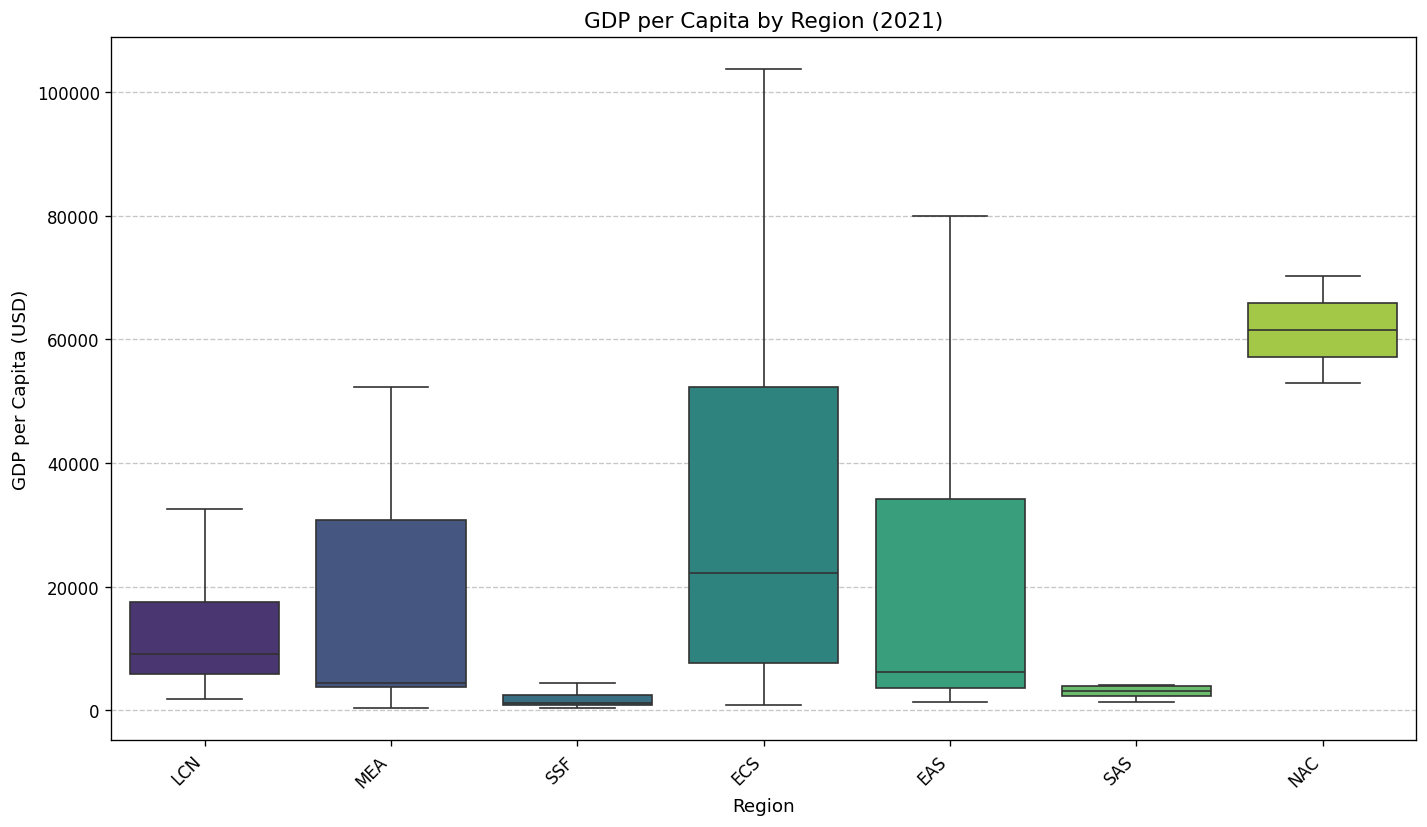

In [ ]:
if 'Region' in df_snap.columns:
    plt.figure(figsize=(12, 7))
    sns.boxplot(data=df_snap, x='Region', y='GDP_per_capita_USD',
                palette='viridis', showfliers=False) # showfliers=False to hide extreme outliers for better readability
    plt.title(f'GDP per Capita by Region ({SNAPSHOT_YEAR})')
    plt.xlabel('Region')
    plt.ylabel('GDP per Capita (USD)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    save_fig('S5f_gdp_by_region_boxplot.png')
    plt.show()
else:
    print("Region column not found in df_snap, cannot generate box plot.")

### Indicators Highly Correlated with GDP per Capita

In [ ]:
if 'GDP_per_capita_USD' in corr.columns:
    gdp_corr = corr['GDP_per_capita_USD'].sort_values(ascending=False)
    # Exclude self-correlation
    gdp_corr = gdp_corr[gdp_corr.index != 'GDP_per_capita_USD']

    print("\n  Top 5 indicators POSITIVELY correlated with GDP per Capita:")
    for indicator, correlation in gdp_corr.head(5).items():
        print(f"     • {indicator:40s}  ρ = {correlation:+.3f}")

    print("\n  Top 5 indicators NEGATIVELY correlated with GDP per Capita:")
    for indicator, correlation in gdp_corr.tail(5).items():
        print(f"     • {indicator:40s}  ρ = {correlation:+.3f}")
else:
    print("GDP_per_capita_USD not found in the correlation matrix.")


  Top 5 indicators POSITIVELY correlated with GDP per Capita:
     • Internet_Users_pct                        ρ = +0.888
     • Life_Expectancy_years                     ρ = +0.847
     • Electricity_Access_pct                    ρ = +0.790
     • Adult_Literacy_pct                        ρ = +0.740
     • Exports_pct_GDP                           ρ = +0.517

  Top 5 indicators NEGATIVELY correlated with GDP per Capita:
     • Arable_Land_pct                           ρ = -0.121
     • Population_total                          ρ = -0.274
     • GINI_Inequality_Index                     ρ = -0.349
     • Inflation_pct                             ρ = -0.357
     • Child_Mortality_per1000                   ρ = -0.866


In [ ]:
# Install kaleido for plotly static image export
!pip install kaleido -q
print("✅ kaleido installed.")

✅ kaleido installed.


  STEP 6 of 13 — Relationship Analysis (statistical tests) ...
  GDP → Life Expectancy                     ρ=+0.847  ↑  p=7.35e-56  ✅
  Electricity → Internet                    ρ=+0.819  ↑  p=7.56e-45  ✅
  Inequality ↔ Income                       ρ=-0.349  ↓  p=1.41e-03  ✅
  Health Spend → Life Exp                   ρ=+0.351  ↑  p=5.59e-07  ✅
  Unemployment → Inequality                 ρ=+0.105  ↑  p=3.53e-01  ❌
  Literacy → GDP                            ρ=+0.740  ↑  p=9.60e-09  ✅
  Child Mortality → Life Exp                ρ=-0.913  ↓  p=1.17e-76  ✅
  Internet Access → GDP                     ρ=+0.888  ↑  p=1.74e-61  ✅
  Education → Life Exp                      ρ=+0.012  ↑  p=8.82e-01  ❌
   💾  Chart saved → figures/S6_relationship_scatters.png


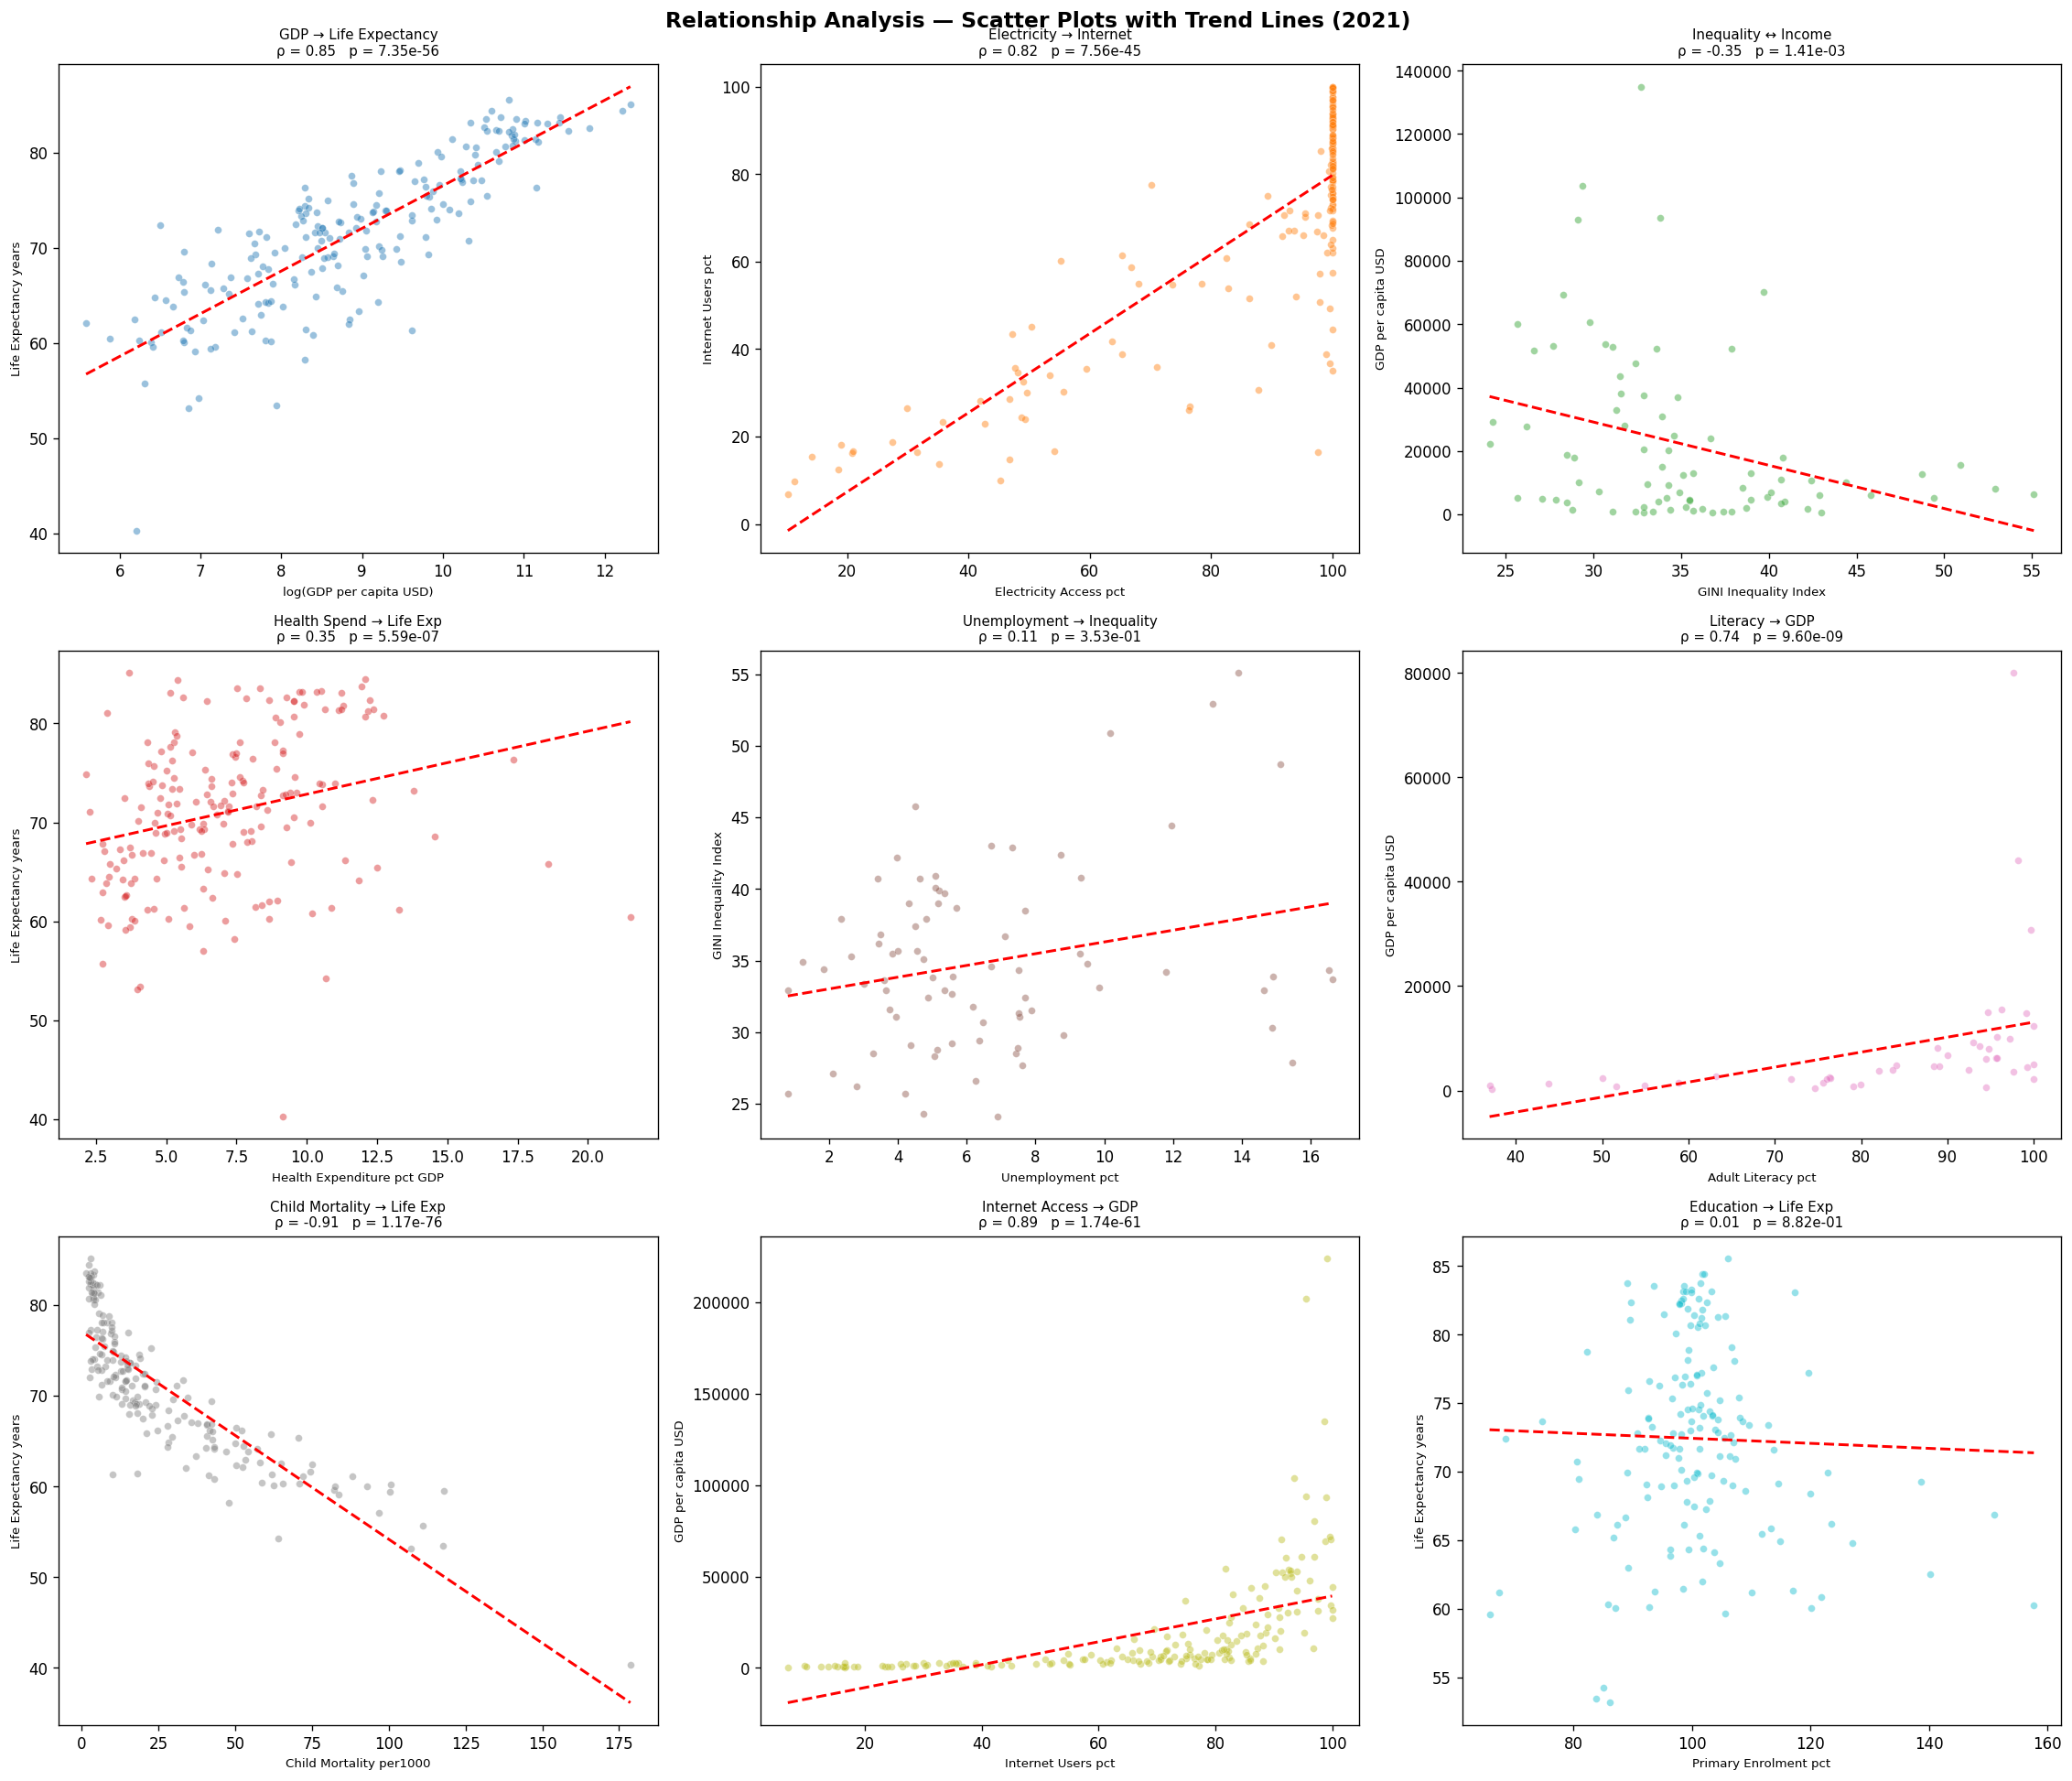


✅  SECTION 6 COMPLETE — Relationship tests saved.



In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6 — RELATIONSHIP ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════
# We test whether the links we see visually are statistically real.
# For each pair of indicators, we measure:
#   ρ (rho) = Spearman rank correlation (-1 to +1)
#   r       = Pearson linear correlation
#   p-value = probability that the link is just random chance (< 0.05 = real)

print("=" * 70)
print("  STEP 6 of 13 — Relationship Analysis (statistical tests) ...")
print("=" * 70)

# Pairs we want to test (based on development economics theory)
PAIRS = [
    ('GDP_per_capita_USD',        'Life_Expectancy_years',      'GDP → Life Expectancy'),
    ('Electricity_Access_pct',    'Internet_Users_pct',         'Electricity → Internet'),
    ('GINI_Inequality_Index',     'GDP_per_capita_USD',         'Inequality ↔ Income'),
    ('Health_Expenditure_pct_GDP','Life_Expectancy_years',      'Health Spend → Life Exp'),
    ('CO2_Emissions_per_capita',  'GDP_per_capita_USD',         'CO₂ ↔ GDP'),
    ('Unemployment_pct',          'GINI_Inequality_Index',      'Unemployment → Inequality'),
    ('Adult_Literacy_pct',        'GDP_per_capita_USD',         'Literacy → GDP'),
    ('Child_Mortality_per1000',   'Life_Expectancy_years',      'Child Mortality → Life Exp'),
    ('Internet_Users_pct',        'GDP_per_capita_USD',         'Internet Access → GDP'),
    ('Primary_Enrolment_pct',     'Life_Expectancy_years',      'Education → Life Exp'),
]

rel_results = []
for (x_col, y_col, label) in PAIRS:
    if x_col not in df_snap.columns or y_col not in df_snap.columns: continue
    sub = df_snap[[x_col, y_col]].dropna()
    if len(sub) < 20: continue

    x, y = sub[x_col].copy(), sub[y_col]
    # Log-transform if the variable is heavily right-skewed
    if abs(x.skew()) > 2: x = np.log1p(x)

    rho, p_sp = stats.spearmanr(x, y)
    r,   p_pe = stats.pearsonr(x, y)

    rel_results.append({
        'Relationship' : label,
        'Spearman_rho' : round(rho, 3),
        'Pearson_r'    : round(r, 3),
        'p_value'      : round(p_sp, 6),
        'n_countries'  : len(sub),
        'Significant'  : '✅ YES' if p_sp < 0.05 else '❌ NO',
        'Strength'     : 'Strong' if abs(rho) > 0.6 else 'Moderate' if abs(rho) > 0.3 else 'Weak'
    })

    direction = '↑' if rho > 0 else '↓'
    print(f"  {label:40s}  ρ={rho:+.3f}  {direction}  p={p_sp:.2e}  "
          f"{'✅' if p_sp < 0.05 else '❌'}")

rel_df = pd.DataFrame(rel_results)
rel_df.to_csv(OUT / "S6_relationship_tests.csv", index=False)

# ── Plot 8: Scatter grid with trend lines ─────────────────────────────────────
valid_pairs = [(x,y,l) for x,y,l in PAIRS
               if x in df_snap.columns and y in df_snap.columns][:9]

n_plot = len(valid_pairs)
n_r, n_c = (3, 3) if n_plot >= 9 else (2, 3)
fig, axes = plt.subplots(n_r, n_c, figsize=(19, n_r * 5.5))
axes = axes.flatten()
colors = plt.cm.tab10(np.linspace(0, 1, n_plot))

for i, (x_col, y_col, label) in enumerate(valid_pairs):
    sub = df_snap[[x_col, y_col]].dropna()
    x_vals = np.log1p(sub[x_col]) if abs(sub[x_col].skew()) > 2 else sub[x_col]
    y_vals = sub[y_col]

    axes[i].scatter(x_vals, y_vals, alpha=0.45, s=22, color=colors[i],
                    edgecolors='white', lw=0.3)
    m, b = np.polyfit(x_vals, y_vals, 1)
    xr   = np.linspace(x_vals.min(), x_vals.max(), 100)
    axes[i].plot(xr, m * xr + b, 'r--', lw=1.8)

    rho, p = stats.spearmanr(x_vals, y_vals)
    axes[i].set_title(f'{label}\nρ = {rho:.2f}   p = {p:.2e}', fontsize=9)
    x_label = f'log({x_col})' if abs(sub[x_col].skew()) > 2 else x_col
    axes[i].set_xlabel(x_label.replace('_', ' '), fontsize=8)
    axes[i].set_ylabel(y_col.replace('_', ' '), fontsize=8)

for j in range(i + 1, len(axes)): axes[j].set_visible(False)

fig.suptitle(f'Relationship Analysis — Scatter Plots with Trend Lines ({SNAPSHOT_YEAR})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig('S6_relationship_scatters.png')
plt.show()

print("\n✅  SECTION 6 COMPLETE — Relationship tests saved.\n")




In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 7 — PREPARE MACHINE LEARNING DATA
# ══════════════════════════════════════════════════════════════════════════════
# Before the ML models, we prepare a clean numeric matrix.
# - Target (what we predict): Life Expectancy
# - Features (what we use to predict): all other indicators
# - Log-transform skewed variables so the models work better

print("=" * 70)
print("  STEP 7 of 13 — Preparing data for Machine Learning ...")
print("=" * 70)

TARGET_COL = 'Life_Expectancy_years'
FEATURE_COLS = [c for c in INDICATOR_COLS if c != TARGET_COL and c in df_snap.columns]

# Apply log transformation to heavily skewed variables
LOG_TRANSFORM = ['GDP_per_capita_USD', 'Population_total', 'CO2_Emissions_per_capita']
df_ml = df_snap.copy()
for col in LOG_TRANSFORM:
    if col in df_ml.columns:
        df_ml[f'log_{col}'] = np.log1p(df_ml[col])
        df_ml.drop(columns=[col], inplace=True)
        # Update FEATURE_COLS to use the log version
        if col in FEATURE_COLS:
            FEATURE_COLS.remove(col)
            FEATURE_COLS.append(f'log_{col}')

FEATURE_COLS = [c for c in FEATURE_COLS if c in df_ml.columns]

# Keep only rows where the target exists
df_ml = df_ml[df_ml[TARGET_COL].notna()]
# Keep only rows with at least half the features filled
df_ml = df_ml.dropna(subset=FEATURE_COLS, thresh=len(FEATURE_COLS) // 2)

print(f"  ML dataset : {len(df_ml)} countries  ×  {len(FEATURE_COLS)} features")
print(f"  Target     : {TARGET_COL}")
print(f"  Features   : {FEATURE_COLS}")

# Build X (features) and y (target)
X_raw = df_ml[FEATURE_COLS].values
y_raw = df_ml[TARGET_COL].values

# Pre-processing pipeline:
#   Step 1: Fill remaining missing values with the median of each column
#   Step 2: Scale all values to a 0-mean, 1-std range (needed for some models)
pre = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

X = pre.fit_transform(X_raw)
y = y_raw

# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"  Train size : {len(X_train)} countries")
print(f"  Test  size : {len(X_test)} countries")
print("\n✅  SECTION 7 COMPLETE — ML data ready.\n")




  STEP 7 of 13 — Preparing data for Machine Learning ...
  ML dataset : 203 countries  ×  13 features
  Target     : Life_Expectancy_years
  Features   : ['Child_Mortality_per1000', 'Electricity_Access_pct', 'Internet_Users_pct', 'Adult_Literacy_pct', 'Primary_Enrolment_pct', 'Health_Expenditure_pct_GDP', 'GINI_Inequality_Index', 'Exports_pct_GDP', 'Inflation_pct', 'Unemployment_pct', 'Arable_Land_pct', 'log_GDP_per_capita_USD', 'log_Population_total']
  Train size : 162 countries
  Test  size : 41 countries

✅  SECTION 7 COMPLETE — ML data ready.



  📊 Random Forest Performance:
     Mean Absolute Error (MAE)  : 2.12 years
       → On average, predictions are off by 2.1 years
     Root Mean Sq Error (RMSE)  : 2.59 years
     R² (explained variance)    : 0.896
       → The model explains 89.6% of variation in life expectancy
     5-fold Cross-Val R²        : 0.846 ± 0.029
   💾  Chart saved → figures/S8a_random_forest.png


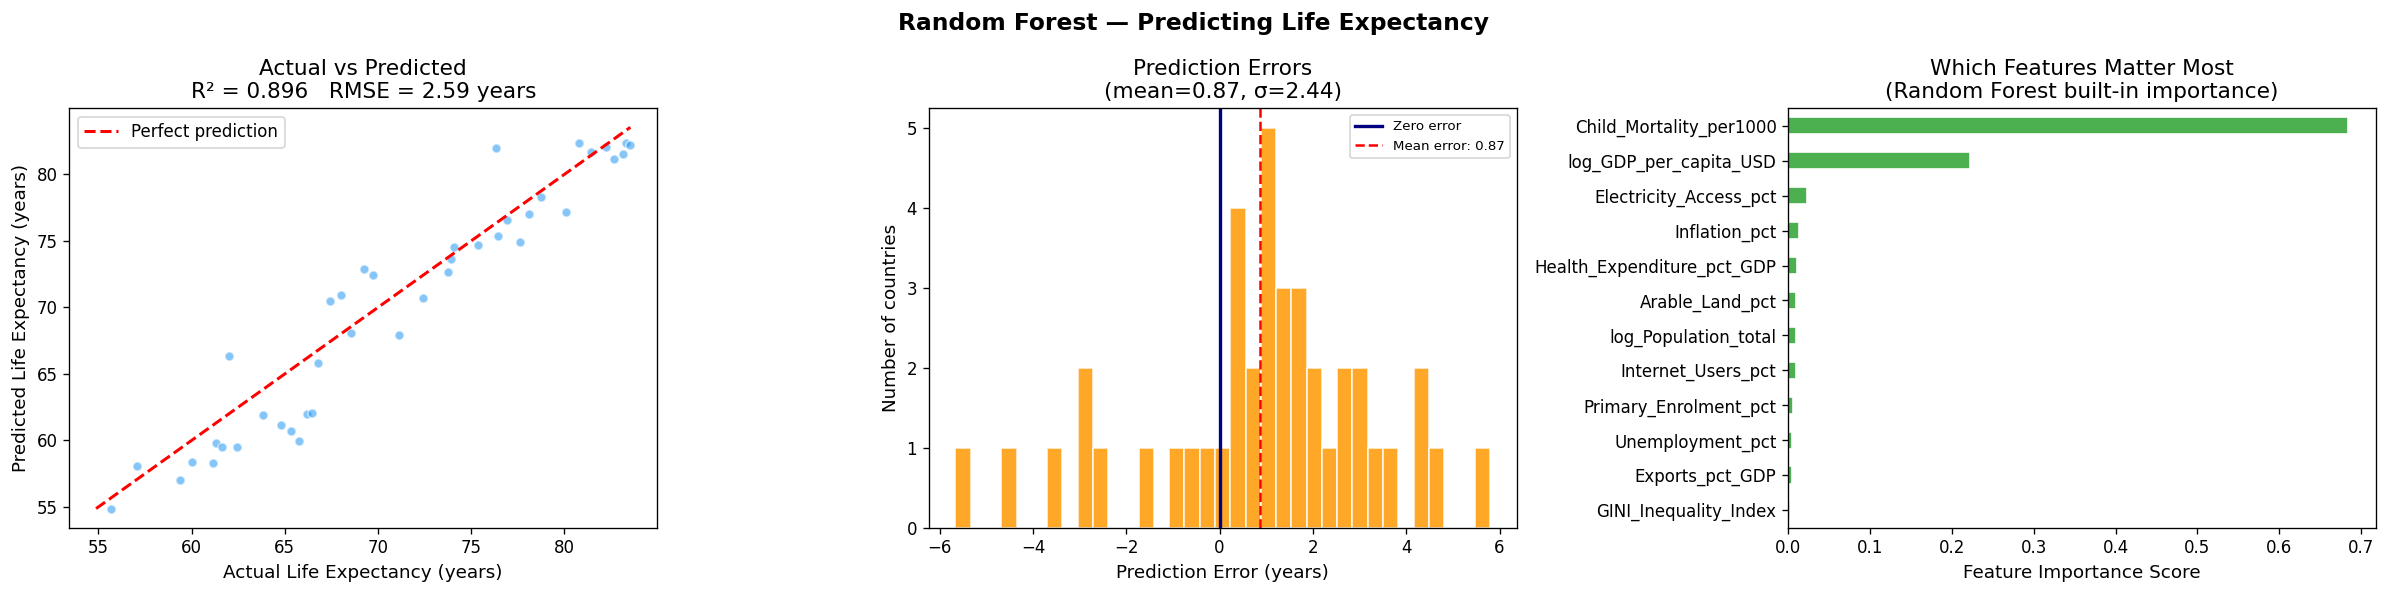


  ⏳ Computing SHAP values (this takes ~30 seconds) ...
   💾  Chart saved → figures/S8b_shap.png


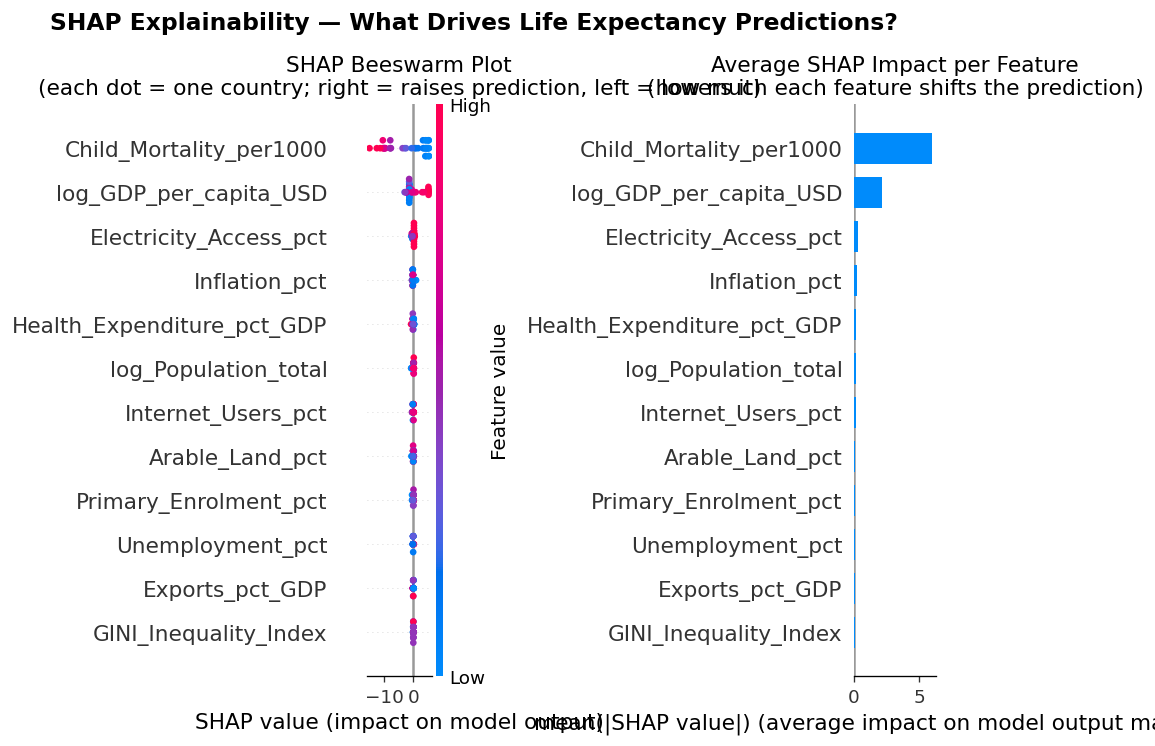


  🔍 SHAP Top 5 drivers of Life Expectancy predictions:
     1. Child_Mortality_per1000                   average impact = ±5.97 years
     2. log_GDP_per_capita_USD                    average impact = ±2.17 years
     3. Electricity_Access_pct                    average impact = ±0.29 years
     4. Inflation_pct                             average impact = ±0.25 years
     5. Health_Expenditure_pct_GDP                average impact = ±0.15 years

✅  SECTION 8 COMPLETE — Random Forest + SHAP done.



In [ ]:
rf = RandomForestRegressor(
    n_estimators  = 300,   # number of trees
    max_depth     = 15,    # max depth of each tree
    min_samples_leaf = 3,  # minimum countries per leaf
    random_state  = 42,
    n_jobs        = -1     # use all CPU cores
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
cv_r2     = cross_val_score(rf, X, y, cv=5, scoring='r2')

mae  = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2   = r2_score(y_test, y_pred_rf)

print(f"  📊 Random Forest Performance:")
print(f"     Mean Absolute Error (MAE)  : {mae:.2f} years")
print(f"       → On average, predictions are off by {mae:.1f} years")
print(f"     Root Mean Sq Error (RMSE)  : {rmse:.2f} years")
print(f"     R² (explained variance)    : {r2:.3f}")
print(f"       → The model explains {r2*100:.1f}% of variation in life expectancy")
print(f"     5-fold Cross-Val R²        : {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# A: Actual vs Predicted
axes[0].scatter(y_test, y_pred_rf, alpha=0.55, color='#2196F3', s=30, edgecolors='white')
lo, hi = min(y_test.min(), y_pred_rf.min()), max(y_test.max(), y_pred_rf.max())
axes[0].plot([lo, hi], [lo, hi], 'r--', lw=1.8, label='Perfect prediction')
axes[0].set_xlabel('Actual Life Expectancy (years)')
axes[0].set_ylabel('Predicted Life Expectancy (years)')
axes[0].set_title(f'Actual vs Predicted\nR² = {r2:.3f}   RMSE = {rmse:.2f} years')
axes[0].legend()

# B: Residuals (prediction errors)
residuals = y_test - y_pred_rf
axes[1].hist(residuals, bins=35, color='#FF9800', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='navy', lw=2, label='Zero error')
axes[1].axvline(residuals.mean(), color='red', lw=1.5, linestyle='--',
                label=f'Mean error: {residuals.mean():.2f}')
axes[1].set_xlabel('Prediction Error (years)')
axes[1].set_ylabel('Number of countries')
axes[1].set_title(f'Prediction Errors\n(mean={residuals.mean():.2f}, σ={residuals.std():.2f})')
axes[1].legend(fontsize=8)

# C: Built-in feature importance
fi = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
fi_top = fi.tail(12)
fi_top.plot(kind='barh', ax=axes[2], color='#4CAF50', edgecolor='white')
axes[2].set_title('Which Features Matter Most\n(Random Forest built-in importance)')
axes[2].set_xlabel('Feature Importance Score')

plt.suptitle('Random Forest — Predicting Life Expectancy', fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig('S8a_random_forest.png')
plt.show()

# ── SHAP Explainability ───────────────────────────────────────────────────────
print("\n  ⏳ Computing SHAP values (this takes ~30 seconds) ...")
explainer = shap.TreeExplainer(rf)
shap_vals = explainer.shap_values(X_test)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# SHAP beeswarm — each dot = one country, colour = feature value
plt.sca(axes[0])
shap.summary_plot(shap_vals, X_test, feature_names=FEATURE_COLS,
                  show=False, max_display=12)
axes[0].set_title('SHAP Beeswarm Plot\n'
                  '(each dot = one country; right = raises prediction, left = lowers it)')

# SHAP bar — average impact of each feature
plt.sca(axes[1])
shap.summary_plot(shap_vals, X_test, feature_names=FEATURE_COLS,
                  plot_type='bar', show=False, max_display=12)
axes[1].set_title('Average SHAP Impact per Feature\n(how much each feature shifts the prediction)')

plt.suptitle('SHAP Explainability — What Drives Life Expectancy Predictions?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig('S8b_shap.png')
plt.show()

# Print SHAP narrative
mean_shap = np.abs(shap_vals).mean(axis=0)
shap_rank = pd.DataFrame({'Feature': FEATURE_COLS, 'Mean_SHAP': mean_shap}) \
              .sort_values('Mean_SHAP', ascending=False)

print(f"\n  🔍 SHAP Top 5 drivers of Life Expectancy predictions:")
for rank, (_, row) in enumerate(shap_rank.head(5).iterrows(), 1):
    print(f"     {rank}. {row['Feature']:40s}  average impact = ±{row['Mean_SHAP']:.2f} years")

print("\n✅  SECTION 8 COMPLETE — Random Forest + SHAP done.\n")

  STEP 9 of 13 — K-Means Clustering (grouping countries) ...
  Best number of clusters : k = 2  (silhouette score = 0.427)
   💾  Chart saved → figures/S9a_kmeans_optimal_k.png


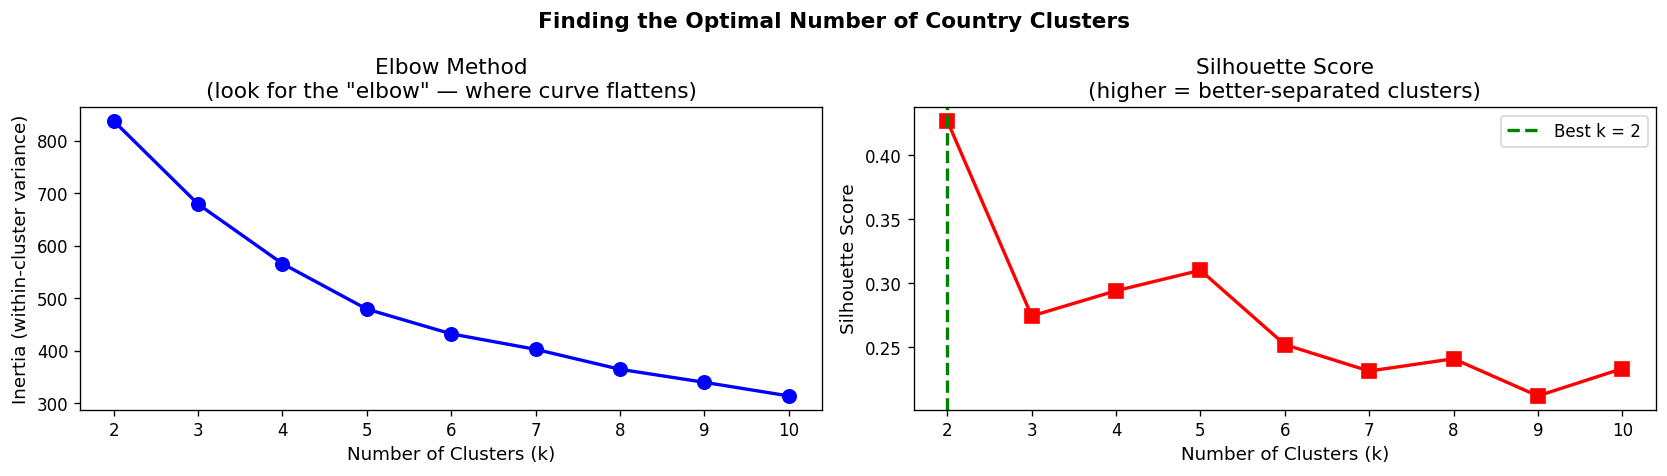


  Cluster Profiles (median values per cluster):
         Life_Expectancy_years  Electricity_Access_pct  Internet_Users_pct  Adult_Literacy_pct  Health_Expenditure_pct_GDP  Child_Mortality_per1000  GINI_Inequality_Index  log_GDP_per_capita_USD
Cluster                                                                                                                                                                                           
0                        73.95                  100.00               82.00               95.22                        7.51                     9.80                  33.70                    9.26
1                        62.40                   50.05               30.18               67.55                        4.39                    56.05                  36.20                    7.16

  Countries per cluster:
     Cluster 0 : 129 countries
     Cluster 1 : 50 countries
   💾  Chart saved → figures/S9b_cluster_heatmap.png


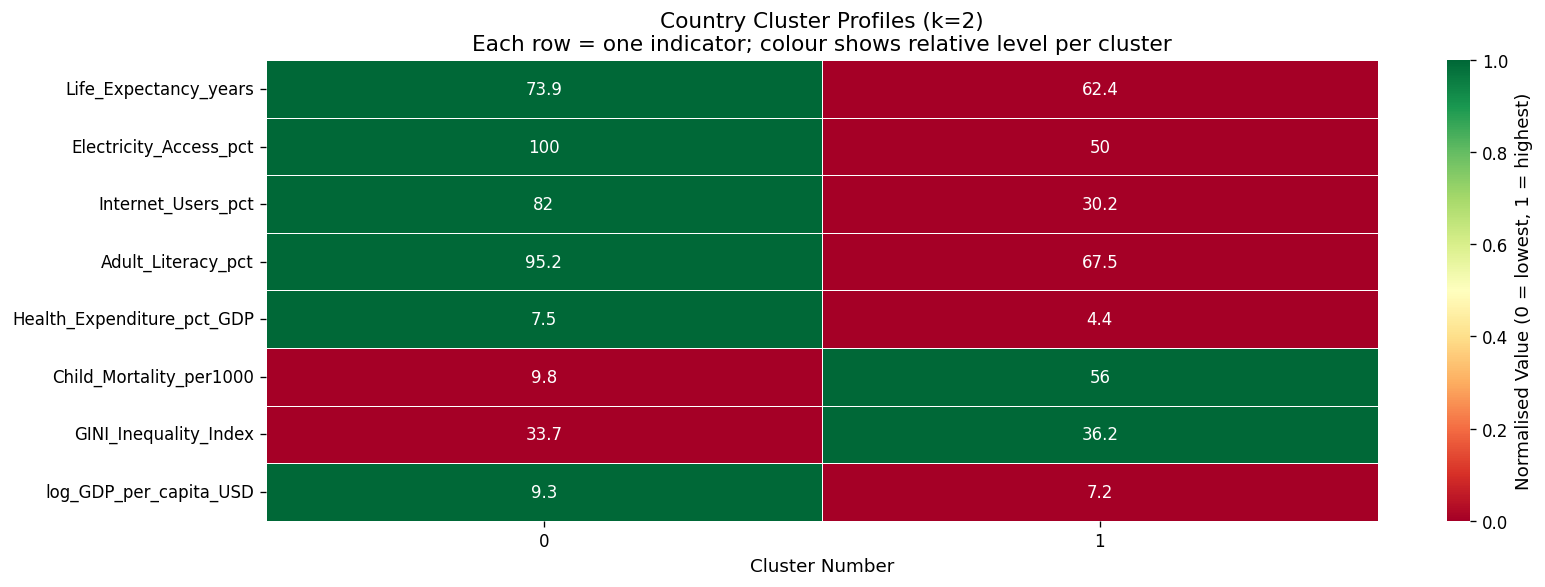

   💾  Chart saved → figures/S9c_cluster_scatter.png


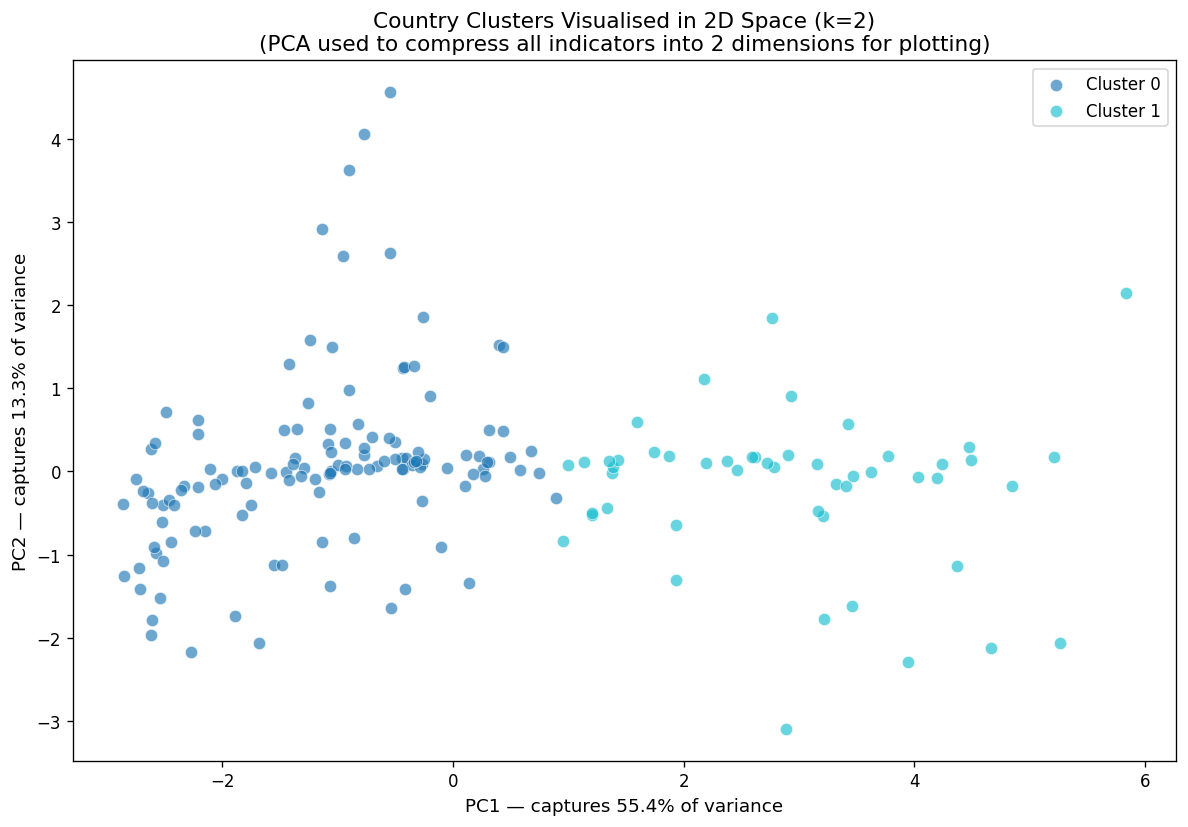


  💾  Country cluster assignments saved → S9_country_clusters.csv

✅  SECTION 9 COMPLETE — K-Means clustering done.



In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 9 — K-MEANS CLUSTERING
# ══════════════════════════════════════════════════════════════════════════════
# K-Means groups countries that are SIMILAR to each other.
# Think of it as sorting 180 countries into k "development buckets"
# automatically, based on all their indicators at once.
#
# We first find the best k (number of groups) using two methods:
#   Elbow Method   — look for where adding more groups stops helping much
#   Silhouette Score — measures how well-separated the groups are

print("=" * 70)
print("  STEP 9 of 13 — K-Means Clustering (grouping countries) ...")
print("=" * 70)

# Use a consistent set of clustering features
CLUSTER_COLS = [c for c in [
    'Life_Expectancy_years', 'Electricity_Access_pct',
    'Internet_Users_pct', 'Adult_Literacy_pct',
    'Health_Expenditure_pct_GDP', 'Child_Mortality_per1000',
    'GINI_Inequality_Index', 'log_GDP_per_capita_USD'
] if c in df_ml.columns]

df_cl = df_ml[CLUSTER_COLS + [c for c in ['Country_Name','Region','Income_Group']
                                if c in df_ml.columns]].dropna(subset=CLUSTER_COLS, thresh=len(CLUSTER_COLS)-2)
pre_cl = Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())])
X_cl   = pre_cl.fit_transform(df_cl[CLUSTER_COLS])

# ── Find the optimal number of clusters ───────────────────────────────────────
K_RANGE    = range(2, 11)
inertias   = []
sil_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cl)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cl, km.labels_))

best_k = list(K_RANGE)[np.argmax(sil_scores)]
print(f"  Best number of clusters : k = {best_k}  "
      f"(silhouette score = {max(sil_scores):.3f})")

# ── Plot Elbow + Silhouette ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(list(K_RANGE), inertias, 'bo-', lw=2, ms=8)
axes[0].set_xlabel('Number of Clusters (k)'); axes[0].set_ylabel('Inertia (within-cluster variance)')
axes[0].set_title('Elbow Method\n(look for the "elbow" — where curve flattens)')

axes[1].plot(list(K_RANGE), sil_scores, 'rs-', lw=2, ms=8)
axes[1].axvline(best_k, color='green', lw=2, linestyle='--', label=f'Best k = {best_k}')
axes[1].set_xlabel('Number of Clusters (k)'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score\n(higher = better-separated clusters)')
axes[1].legend()

plt.suptitle('Finding the Optimal Number of Country Clusters', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('S9a_kmeans_optimal_k.png')
plt.show()

# ── Fit final model ───────────────────────────────────────────────────────────
km = KMeans(n_clusters=best_k, random_state=42, n_init=15)
df_cl['Cluster'] = km.fit_predict(X_cl)

# ── Cluster profiles ──────────────────────────────────────────────────────────
profile = df_cl.groupby('Cluster')[CLUSTER_COLS].median()
profile.to_csv(OUT / "S9_cluster_profiles.csv")

print(f"\n  Cluster Profiles (median values per cluster):")
print(profile.round(2).to_string())

print(f"\n  Countries per cluster:")
for c, n in df_cl['Cluster'].value_counts().sort_index().items():
    print(f"     Cluster {c} : {n} countries")

# ── Plot Cluster Profile Heatmap ──────────────────────────────────────────────
profile_norm = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(profile_norm.T, annot=profile.T.round(1), fmt='g',
            cmap='RdYlGn', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Normalised Value (0 = lowest, 1 = highest)'})
ax.set_title(f'Country Cluster Profiles (k={best_k})\n'
             'Each row = one indicator; colour shows relative level per cluster',
             fontsize=13)
ax.set_xlabel('Cluster Number'); ax.set_ylabel('')
plt.tight_layout()
save_fig('S9b_cluster_heatmap.png')
plt.show()

# ── Plot Clusters in 2D space (using PCA to reduce dimensions) ────────────────
pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_cl)
df_cl['PC1'] = X_2d[:, 0]
df_cl['PC2'] = X_2d[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, best_k))
for c in range(best_k):
    mask = df_cl['Cluster'] == c
    ax.scatter(df_cl.loc[mask, 'PC1'], df_cl.loc[mask, 'PC2'],
               alpha=0.65, s=55, color=colors[c], label=f'Cluster {c}',
               edgecolors='white', lw=0.5)

ax.set_xlabel(f'PC1 — captures {pca2.explained_variance_ratio_[0]*100:.1f}% of variance')
ax.set_ylabel(f'PC2 — captures {pca2.explained_variance_ratio_[1]*100:.1f}% of variance')
ax.set_title(f'Country Clusters Visualised in 2D Space (k={best_k})\n'
             '(PCA used to compress all indicators into 2 dimensions for plotting)')
ax.legend(fontsize=10)
plt.tight_layout()
save_fig('S9c_cluster_scatter.png')
plt.show()

# Save country-cluster assignments
if 'Country_Name' in df_cl.columns:
    df_cl[[c for c in ['Country_Name','Cluster','Region','Income_Group'] + CLUSTER_COLS
           if c in df_cl.columns]].to_csv(OUT / "S9_country_clusters.csv", index=False)
    print(f"\n  💾  Country cluster assignments saved → S9_country_clusters.csv")

print("\n✅  SECTION 9 COMPLETE — K-Means clustering done.\n")




  STEP 10 of 13 — Logistic Regression (classify countries) ...
  Split threshold : 71.7 years (global median life expectancy)
  Class 1 = countries ABOVE 71.7 years  (Higher development)
  Class 0 = countries BELOW 71.7 years  (Lower development)

  📊 Logistic Regression Performance:
     AUC-ROC (area under curve)  : 0.929
       → 1.0 = perfect, 0.5 = random guessing
     5-fold CV AUC               : 0.934 ± 0.012

  Classification Report:
              precision    recall  f1-score   support

   Lower Dev       1.00      0.75      0.86        20
  Higher Dev       0.79      1.00      0.88        19

    accuracy                           0.87        39
   macro avg       0.90      0.88      0.87        39
weighted avg       0.90      0.87      0.87        39

   💾  Chart saved → figures/S10_logistic_regression.png


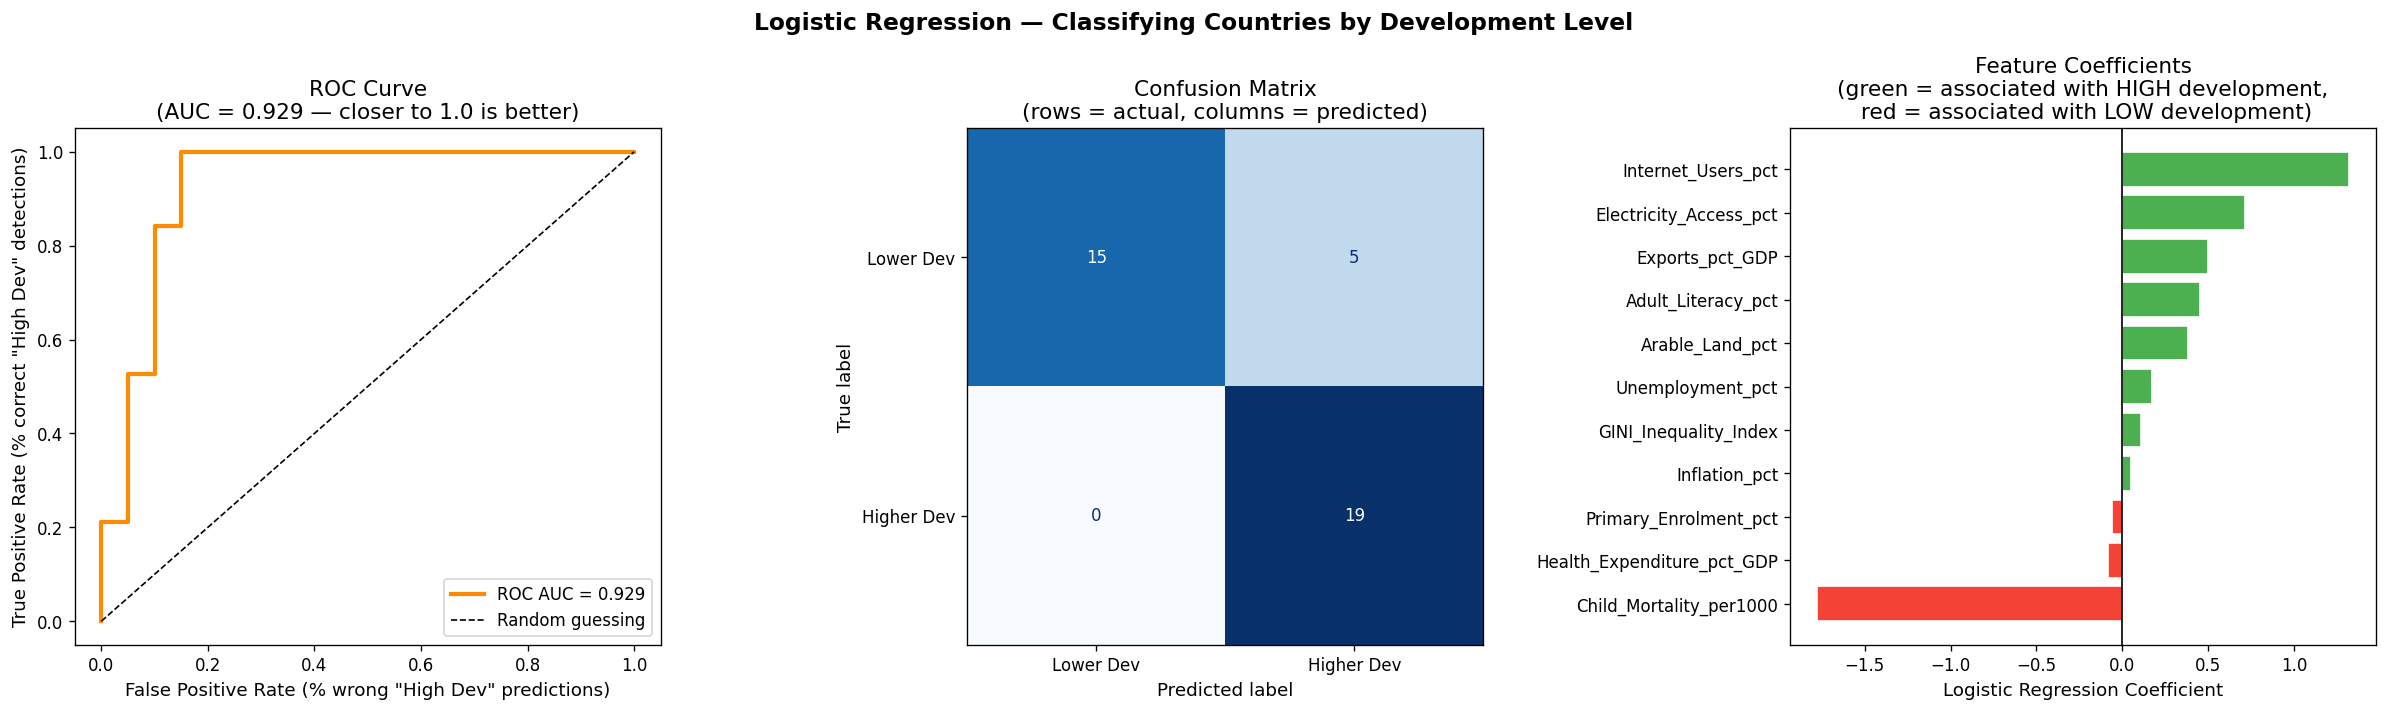


✅  SECTION 10 COMPLETE — Logistic regression done.



In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 10 — LOGISTIC REGRESSION
# ══════════════════════════════════════════════════════════════════════════════
# Logistic Regression classifies countries as "High Development" or "Low Development".
# We define the split at the median life expectancy.
# The model gives us a probability (0–100%) for each country.
# The ROC curve shows how well it separates the two groups.

print("=" * 70)
print("  STEP 10 of 13 — Logistic Regression (classify countries) ...")
print("=" * 70)

le_median = df_snap['Life_Expectancy_years'].median()
print(f"  Split threshold : {le_median:.1f} years (global median life expectancy)")
print(f"  Class 1 = countries ABOVE {le_median:.1f} years  (Higher development)")
print(f"  Class 0 = countries BELOW {le_median:.1f} years  (Lower development)")

df_lr = df_snap.copy()
df_lr['High_LE'] = (df_lr['Life_Expectancy_years'] >= le_median).astype(int)

LR_FEAT_COLS = [c for c in FEATURE_COLS if c in df_lr.columns]
df_lr_valid  = df_lr[LR_FEAT_COLS + ['High_LE']].dropna(
    thresh=len(LR_FEAT_COLS) // 2 + 1)

X_lr = pre.fit_transform(df_lr_valid[LR_FEAT_COLS])
y_lr = df_lr_valid['High_LE'].values

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42, stratify=y_lr
)

lr = LogisticRegression(max_iter=2000, C=0.5, random_state=42, class_weight='balanced')
lr.fit(X_tr2, y_tr2)

y_pred_lr = lr.predict(X_te2)
y_prob_lr = lr.predict_proba(X_te2)[:, 1]
auc_score = roc_auc_score(y_te2, y_prob_lr)
cv_auc    = cross_val_score(lr, X_lr, y_lr, cv=5, scoring='roc_auc')

print(f"\n  📊 Logistic Regression Performance:")
print(f"     AUC-ROC (area under curve)  : {auc_score:.3f}")
print(f"       → 1.0 = perfect, 0.5 = random guessing")
print(f"     5-fold CV AUC               : {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")
print(f"\n  Classification Report:")
print(classification_report(y_te2, y_pred_lr,
                             target_names=['Lower Dev','Higher Dev']))

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# A: ROC Curve
fpr, tpr, _ = roc_curve(y_te2, y_prob_lr)
axes[0].plot(fpr, tpr, color='darkorange', lw=2.5,
             label=f'ROC AUC = {auc_score:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random guessing')
axes[0].set_xlabel('False Positive Rate (% wrong "High Dev" predictions)')
axes[0].set_ylabel('True Positive Rate (% correct "High Dev" detections)')
axes[0].set_title(f'ROC Curve\n(AUC = {auc_score:.3f} — closer to 1.0 is better)')
axes[0].legend()

# B: Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_te2, y_pred_lr, display_labels=['Lower Dev', 'Higher Dev'],
    ax=axes[1], colorbar=False, cmap='Blues'
)
axes[1].set_title('Confusion Matrix\n(rows = actual, columns = predicted)')

# C: Coefficient Bar Chart
coef_df = pd.DataFrame({'Feature': LR_FEAT_COLS, 'Coefficient': lr.coef_[0]}) \
            .sort_values('Coefficient')
bar_colors = ['#F44336' if c < 0 else '#4CAF50' for c in coef_df['Coefficient']]
axes[2].barh(coef_df['Feature'], coef_df['Coefficient'],
             color=bar_colors, edgecolor='white')
axes[2].axvline(0, color='black', lw=1)
axes[2].set_title('Feature Coefficients\n'
                  '(green = associated with HIGH development,\n'
                  ' red = associated with LOW development)')
axes[2].set_xlabel('Logistic Regression Coefficient')

plt.suptitle('Logistic Regression — Classifying Countries by Development Level',
             fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig('S10_logistic_regression.png')
plt.show()

print("\n✅  SECTION 10 COMPLETE — Logistic regression done.\n")




  STEP 11 of 13 — Principal Component Analysis (PCA) ...
  Number of components to explain 95% of variance : 10  (out of 13 original features)
  PC1 explains : 29.7% of all variation
  PC2 explains : 11.5% of all variation
  PC1+PC2 combined : 41.2%
   💾  Chart saved → figures/S11_pca.png


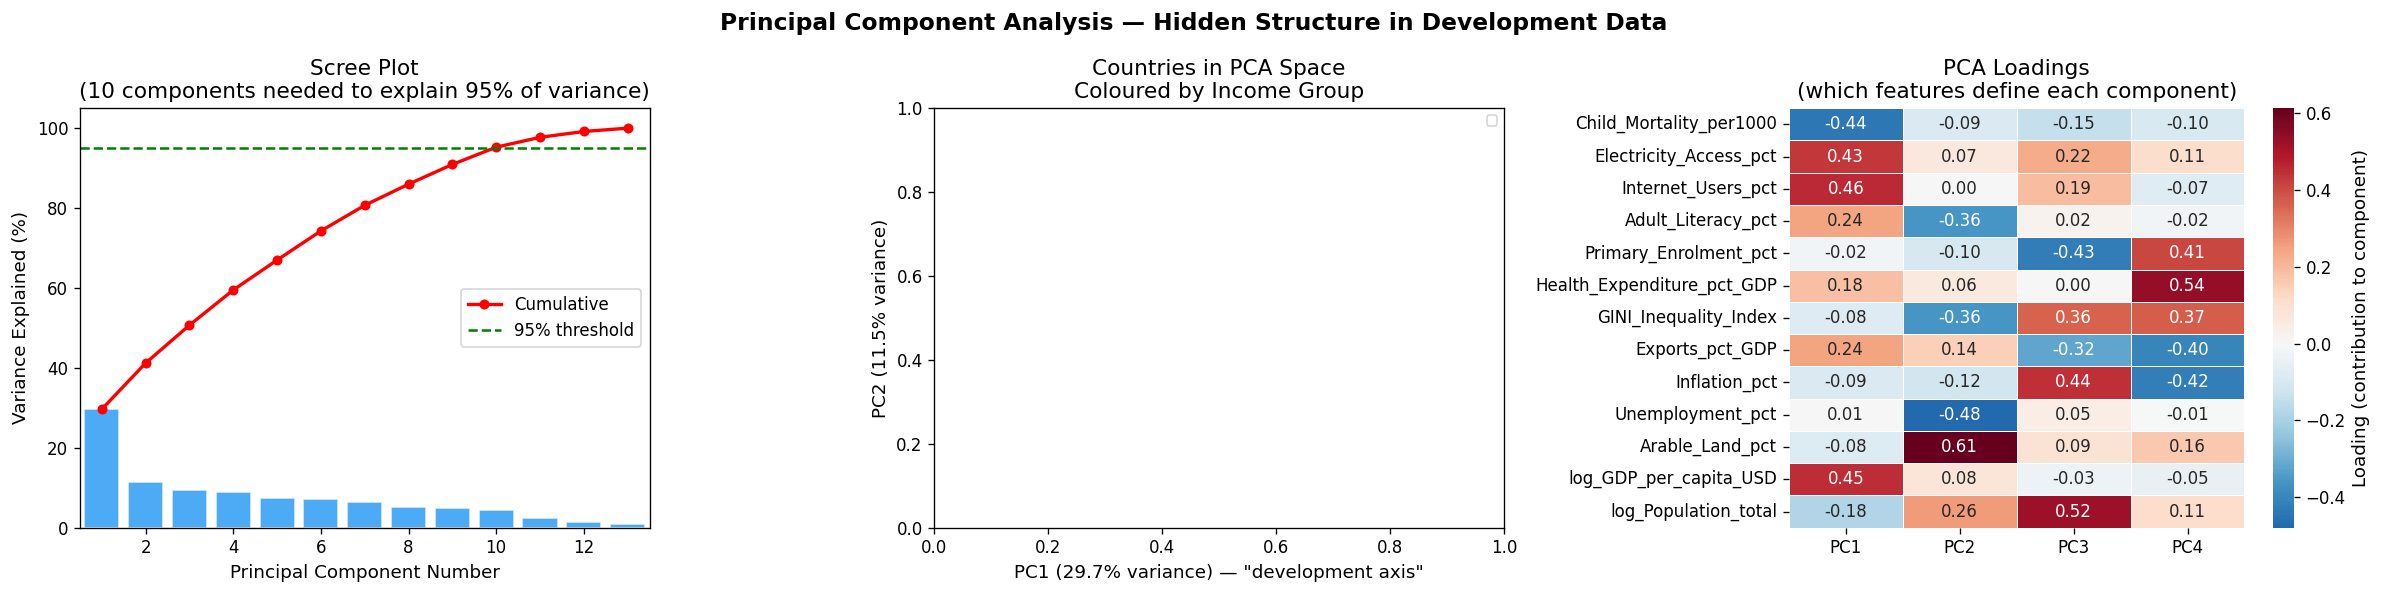


  PC1 (the main development axis) is most defined by:
     Internet_Users_pct                        |loading| = 0.456  (↑ higher = richer)
     log_GDP_per_capita_USD                    |loading| = 0.452  (↑ higher = richer)
     Child_Mortality_per1000                   |loading| = 0.443  (↓ higher = poorer)
     Electricity_Access_pct                    |loading| = 0.429  (↑ higher = richer)
     Adult_Literacy_pct                        |loading| = 0.245  (↑ higher = richer)

✅  SECTION 11 COMPLETE — PCA done.



In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 11 — PRINCIPAL COMPONENT ANALYSIS  (Bonus)
# ══════════════════════════════════════════════════════════════════════════════
# PCA finds the hidden structure in the data.
# It compresses 15 indicators into 2–3 "super-dimensions" that capture
# most of the variation. The first component typically represents an
# overall "development axis" from poor to rich countries.

print("=" * 70)
print("  STEP 11 of 13 — Principal Component Analysis (PCA) ...")
print("=" * 70)

pca_full = PCA(random_state=42)
pca_full.fit(X)  # use the same preprocessed data as Random Forest

evr     = pca_full.explained_variance_ratio_
cum_evr = np.cumsum(evr)
n_95    = np.searchsorted(cum_evr, 0.95) + 1

print(f"  Number of components to explain 95% of variance : {n_95}  "
      f"(out of {len(FEATURE_COLS)} original features)")
print(f"  PC1 explains : {evr[0]*100:.1f}% of all variation")
print(f"  PC2 explains : {evr[1]*100:.1f}% of all variation")
print(f"  PC1+PC2 combined : {sum(evr[:2])*100:.1f}%")

pca3 = PCA(n_components=min(4, len(FEATURE_COLS)), random_state=42)
X_pca = pca3.fit_transform(X)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# A: Scree Plot
axes[0].bar(range(1, len(evr)+1), evr * 100, color='#2196F3', edgecolor='white', alpha=0.8)
axes[0].plot(range(1, len(evr)+1), cum_evr * 100, 'r-o', ms=5, lw=2, label='Cumulative')
axes[0].axhline(95, color='green', linestyle='--', lw=1.5, label='95% threshold')
axes[0].set_xlabel('Principal Component Number')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title(f'Scree Plot\n({n_95} components needed to explain 95% of variance)')
axes[0].legend(); axes[0].set_xlim(0.5, min(15, len(evr)) + 0.5)

# B: Countries in PC1 vs PC2 space, coloured by income group
if 'Income_Group' in df_ml.columns:
    inc_vals = df_ml.loc[df_ml.index[:len(X_pca)], 'Income_Group'].values
    unique_groups = [g for g in ['Low income','Lower middle income',
                                  'Upper middle income','High income'] if g in inc_vals]
    colors2 = {'Low income': '#F44336', 'Lower middle income': '#FF9800',
                'Upper middle income': '#2196F3', 'High income': '#4CAF50'}
    for grp in unique_groups:
        mask = inc_vals == grp
        axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                        alpha=0.55, s=30, color=colors2.get(grp, 'grey'),
                        label=grp, edgecolors='white', lw=0.3)
    axes[1].legend(fontsize=8)

axes[1].set_xlabel(f'PC1 ({evr[0]*100:.1f}% variance) — "development axis"')
axes[1].set_ylabel(f'PC2 ({evr[1]*100:.1f}% variance)')
axes[1].set_title('Countries in PCA Space\nColoured by Income Group')

# C: Loading heatmap — which original features make up each component
n_comp = min(4, pca3.n_components_)
loadings = pd.DataFrame(
    pca3.components_[:n_comp].T,
    index   = FEATURE_COLS,
    columns = [f'PC{i+1}' for i in range(n_comp)]
)
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[2], linewidths=0.5,
            cbar_kws={'label': 'Loading (contribution to component)'})
axes[2].set_title('PCA Loadings\n(which features define each component)')

plt.suptitle('Principal Component Analysis — Hidden Structure in Development Data',
             fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig('S11_pca.png')
plt.show()

# Interpret PC1
top_pc1 = loadings['PC1'].abs().sort_values(ascending=False).head(5)
print(f"\n  PC1 (the main development axis) is most defined by:")
for feat, val in top_pc1.items():
    direction = "↑ higher = richer" if loadings.loc[feat, 'PC1'] > 0 else "↓ higher = poorer"
    print(f"     {feat:40s}  |loading| = {val:.3f}  ({direction})")

print("\n✅  SECTION 11 COMPLETE — PCA done.\n")




# ══════════════════════════════════════════════════════════════════════════════
# SECTION 11a — GDP REGRESSION ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════


  STEP 11a of 13 — GDP Regression Analysis (predict GDP per Capita) ...
  ML dataset (GDP) : 199 countries  ×  13 features
  Target           : log_GDP_per_capita_USD
  Features         : ['Life_Expectancy_years', 'Child_Mortality_per1000', 'Electricity_Access_pct', 'Internet_Users_pct', 'Adult_Literacy_pct', 'Primary_Enrolment_pct', 'Health_Expenditure_pct_GDP', 'GINI_Inequality_Index', 'Exports_pct_GDP', 'Inflation_pct', 'Unemployment_pct', 'Arable_Land_pct', 'log_Population_total']
  Train size (GDP) : 159 countries
  Test  size (GDP) : 40 countries

  📊 Random Forest (GDP) Performance:
     Mean Absolute Error (MAE)  : 0.42 (log USD)
     Root Mean Sq Error (RMSE)  : 0.54 (log USD)
     R² (explained variance)    : 0.862
       → The model explains 86.2% of variation in log GDP per capita
     5-fold Cross-Val R²        : 0.831 ± 0.061
   💾  Chart saved → figures/S11a_gdp_random_forest.png


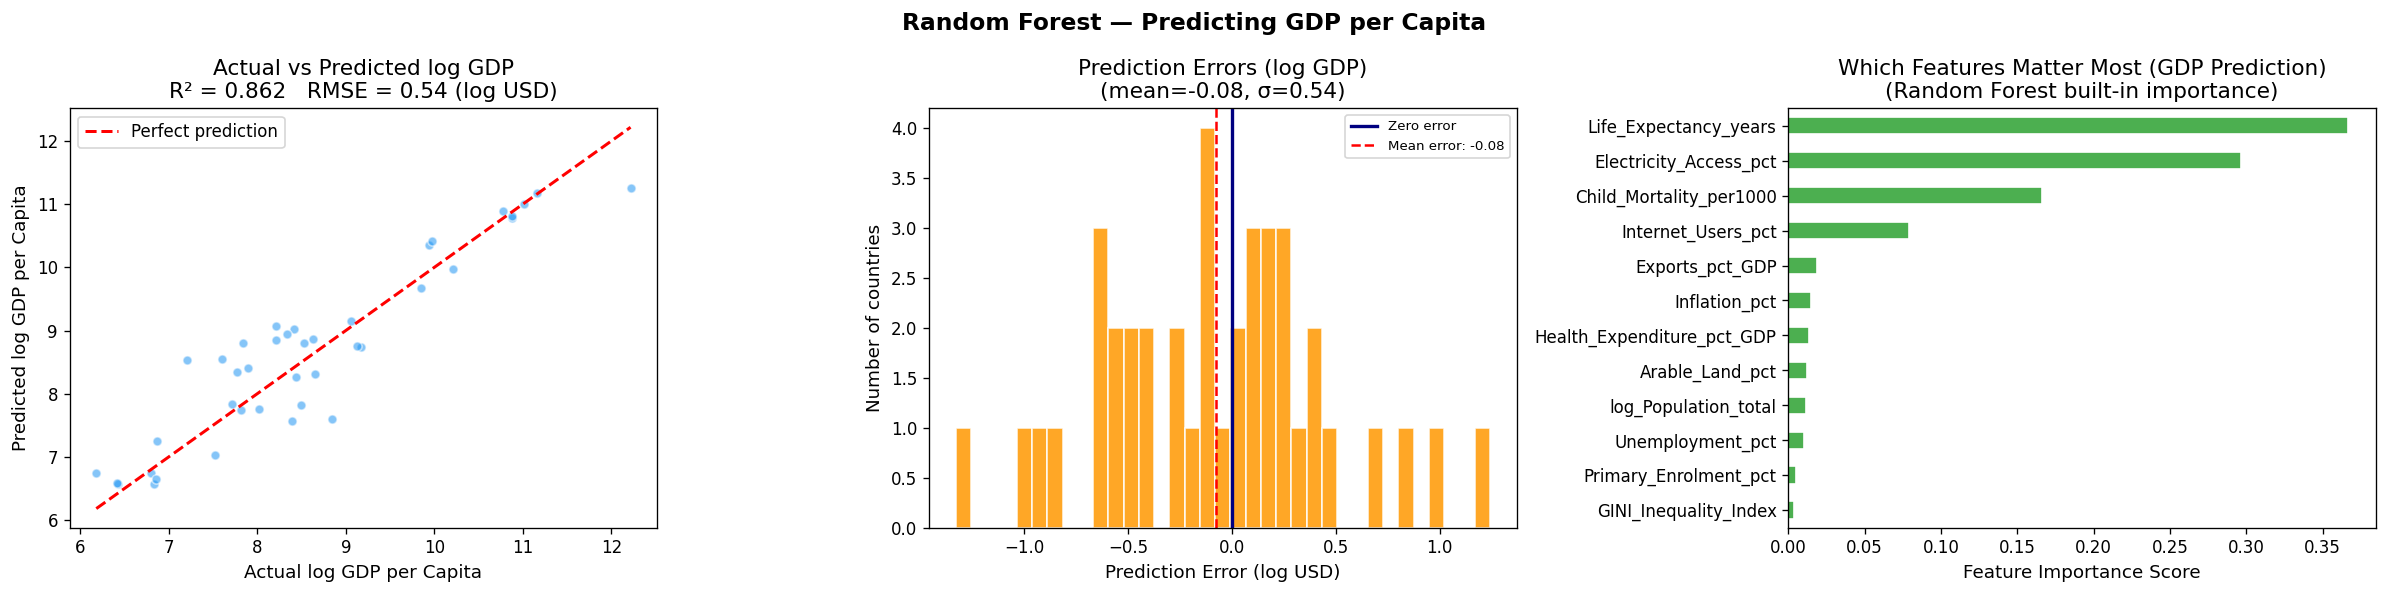


  ⏳ Computing SHAP values for GDP (this takes ~30 seconds) ...
   💾  Chart saved → figures/S11b_gdp_shap.png


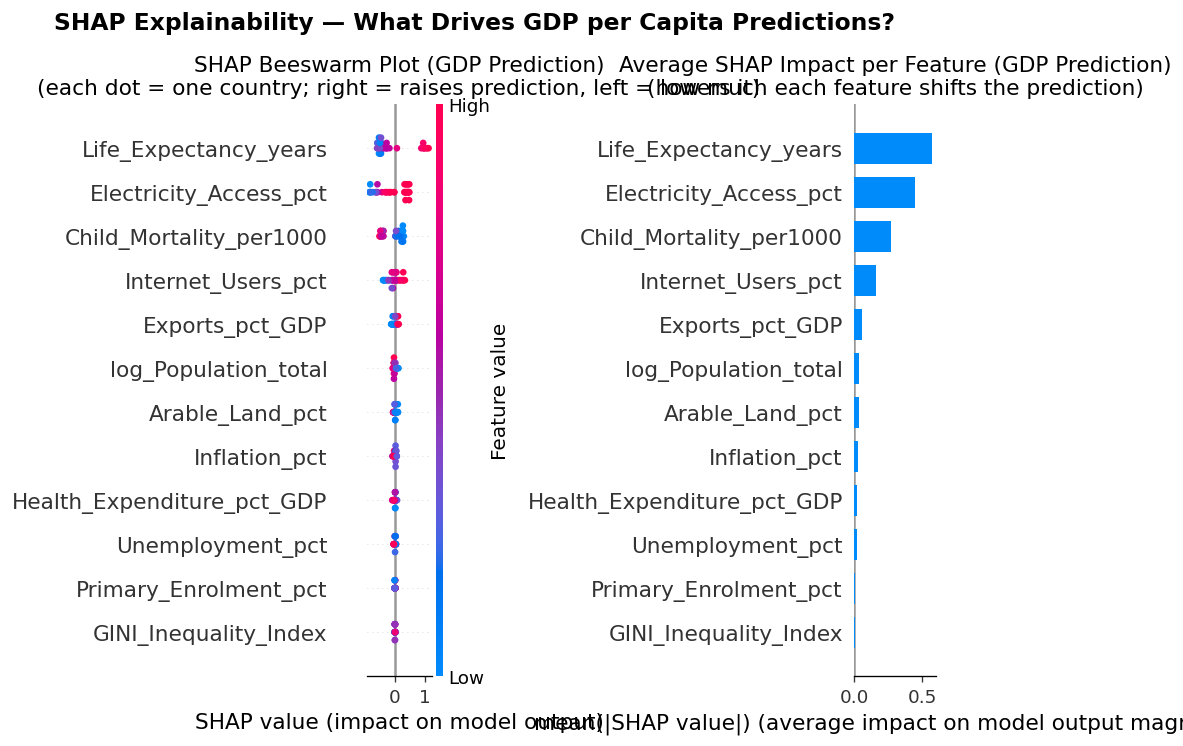


  🔍 SHAP Top 5 drivers of GDP per Capita predictions:
     1. Life_Expectancy_years                     average impact = ±0.57 (log USD)
     2. Electricity_Access_pct                    average impact = ±0.45 (log USD)
     3. Child_Mortality_per1000                   average impact = ±0.27 (log USD)
     4. Internet_Users_pct                        average impact = ±0.16 (log USD)
     5. Exports_pct_GDP                           average impact = ±0.06 (log USD)

✅  SECTION 11a COMPLETE — GDP Regression analysis done.



In [ ]:
# Pre-processing pipeline (re-defined to ensure availability)
pre = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

print("=" * 70)
print("  STEP 11a of 13 — GDP Regression Analysis (predict GDP per Capita) ...")
print("=" * 70)

GDP_TARGET_COL = 'log_GDP_per_capita_USD'

# Re-use the existing FEATURE_COLS but adjust for the new target
GDP_FEATURE_COLS = [c for c in INDICATOR_COLS if c != 'GDP_per_capita_USD' and c in df_snap.columns]

# Prepare data for GDP prediction
df_ml_gdp = df_snap.copy()

# Apply log transformation to heavily skewed variables, including the new target
GDP_LOG_TRANSFORM = ['Population_total', 'CO2_Emissions_per_capita'] # GDP itself is now the target
for col in GDP_LOG_TRANSFORM:
    if col in df_ml_gdp.columns:
        df_ml_gdp[f'log_{col}'] = np.log1p(df_ml_gdp[col])
        df_ml_gdp.drop(columns=[col], inplace=True)
        if col in GDP_FEATURE_COLS:
            GDP_FEATURE_COLS.remove(col)
            GDP_FEATURE_COLS.append(f'log_{col}')

# Log transform the GDP target column
if 'GDP_per_capita_USD' in df_ml_gdp.columns:
    df_ml_gdp[GDP_TARGET_COL] = np.log1p(df_ml_gdp['GDP_per_capita_USD'])
    df_ml_gdp.drop(columns=['GDP_per_capita_USD'], inplace=True)

# Filter features to only include those present in df_ml_gdp
GDP_FEATURE_COLS = [c for c in GDP_FEATURE_COLS if c in df_ml_gdp.columns]

# Keep only rows where the target exists
df_ml_gdp = df_ml_gdp[df_ml_gdp[GDP_TARGET_COL].notna()]
# Keep only rows with at least half the features filled
df_ml_gdp = df_ml_gdp.dropna(subset=GDP_FEATURE_COLS, thresh=len(GDP_FEATURE_COLS) // 2)

print(f"  ML dataset (GDP) : {len(df_ml_gdp)} countries  ×  {len(GDP_FEATURE_COLS)} features")
print(f"  Target           : {GDP_TARGET_COL}")
print(f"  Features         : {GDP_FEATURE_COLS}")

# Build X (features) and y (target)
X_gdp_raw = df_ml_gdp[GDP_FEATURE_COLS].values
y_gdp_raw = df_ml_gdp[GDP_TARGET_COL].values

# Pre-processing (re-use existing 'pre' pipeline)
X_gdp = pre.fit_transform(X_gdp_raw)
y_gdp = y_gdp_raw

# Split into training (80%) and testing (20%)
X_gdp_train, X_gdp_test, y_gdp_train, y_gdp_test = train_test_split(
    X_gdp, y_gdp, test_size=0.2, random_state=42
)

print(f"  Train size (GDP) : {len(X_gdp_train)} countries")
print(f"  Test  size (GDP) : {len(X_gdp_test)} countries")

# Train Random Forest Regressor
rf_gdp = RandomForestRegressor(
    n_estimators  = 300,
    max_depth     = 15,
    min_samples_leaf = 3,
    random_state  = 42,
    n_jobs         = -1
)
rf_gdp.fit(X_gdp_train, y_gdp_train)

y_gdp_pred_rf = rf_gdp.predict(X_gdp_test)
cv_gdp_r2     = cross_val_score(rf_gdp, X_gdp, y_gdp, cv=5, scoring='r2')

mae_gdp  = mean_absolute_error(y_gdp_test, y_gdp_pred_rf)
rmse_gdp = np.sqrt(mean_squared_error(y_gdp_test, y_gdp_pred_rf))
r2_gdp   = r2_score(y_gdp_test, y_gdp_pred_rf)

print(f"\n  📊 Random Forest (GDP) Performance:")
print(f"     Mean Absolute Error (MAE)  : {mae_gdp:.2f} (log USD)")
print(f"     Root Mean Sq Error (RMSE)  : {rmse_gdp:.2f} (log USD)")
print(f"     R² (explained variance)    : {r2_gdp:.3f}")
print(f"       → The model explains {r2_gdp*100:.1f}% of variation in log GDP per capita")
print(f"     5-fold Cross-Val R²        : {cv_gdp_r2.mean():.3f} ± {cv_gdp_r2.std():.3f}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig_gdp, axes_gdp = plt.subplots(1, 3, figsize=(20, 5))

# A: Actual vs Predicted
axes_gdp[0].scatter(y_gdp_test, y_gdp_pred_rf, alpha=0.55, color='#2196F3', s=30, edgecolors='white')
lo_gdp, hi_gdp = min(y_gdp_test.min(), y_gdp_pred_rf.min()), max(y_gdp_test.max(), y_gdp_pred_rf.max())
axes_gdp[0].plot([lo_gdp, hi_gdp], [lo_gdp, hi_gdp], 'r--', lw=1.8, label='Perfect prediction')
axes_gdp[0].set_xlabel('Actual log GDP per Capita')
axes_gdp[0].set_ylabel('Predicted log GDP per Capita')
axes_gdp[0].set_title(f'Actual vs Predicted log GDP\nR² = {r2_gdp:.3f}   RMSE = {rmse_gdp:.2f} (log USD)')
axes_gdp[0].legend()

# B: Residuals (prediction errors)
residuals_gdp = y_gdp_test - y_gdp_pred_rf
axes_gdp[1].hist(residuals_gdp, bins=35, color='#FF9800', edgecolor='white', alpha=0.85)
axes_gdp[1].axvline(0, color='navy', lw=2, label='Zero error')
axes_gdp[1].axvline(residuals_gdp.mean(), color='red', lw=1.5, linestyle='--', label=f'Mean error: {residuals_gdp.mean():.2f}')
axes_gdp[1].set_xlabel('Prediction Error (log USD)')
axes_gdp[1].set_ylabel('Number of countries')
axes_gdp[1].set_title(f'Prediction Errors (log GDP)\n(mean={residuals_gdp.mean():.2f}, σ={residuals_gdp.std():.2f})')
axes_gdp[1].legend(fontsize=8)

# C: Built-in feature importance
fi_gdp = pd.Series(rf_gdp.feature_importances_, index=GDP_FEATURE_COLS).sort_values(ascending=True)
fi_gdp_top = fi_gdp.tail(12)
fi_gdp_top.plot(kind='barh', ax=axes_gdp[2], color='#4CAF50', edgecolor='white')
axes_gdp[2].set_title('Which Features Matter Most (GDP Prediction)\n(Random Forest built-in importance)')
axes_gdp[2].set_xlabel('Feature Importance Score')

plt.suptitle('Random Forest — Predicting GDP per Capita', fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig('S11a_gdp_random_forest.png')
plt.show()

# ── SHAP Explainability ───────────────────────────────────────────────────────
print("\n  ⏳ Computing SHAP values for GDP (this takes ~30 seconds) ...")
explainer_gdp = shap.TreeExplainer(rf_gdp)
shap_vals_gdp = explainer_gdp.shap_values(X_gdp_test)

fig_shap_gdp, axes_shap_gdp = plt.subplots(1, 2, figsize=(20, 8))

# SHAP beeswarm — each dot = one country, colour = feature value
plt.sca(axes_shap_gdp[0])
shap.summary_plot(shap_vals_gdp, X_gdp_test, feature_names=GDP_FEATURE_COLS,
                  show=False, max_display=12)
axes_shap_gdp[0].set_title('SHAP Beeswarm Plot (GDP Prediction)\n' + \
                          '(each dot = one country; right = raises prediction, left = lowers it)')

# SHAP bar — average impact of each feature
plt.sca(axes_shap_gdp[1])
shap.summary_plot(shap_vals_gdp, X_gdp_test, feature_names=GDP_FEATURE_COLS,
                  plot_type='bar', show=False, max_display=12)
axes_shap_gdp[1].set_title('Average SHAP Impact per Feature (GDP Prediction)\n' + \
                           '(how much each feature shifts the prediction)')

plt.suptitle('SHAP Explainability — What Drives GDP per Capita Predictions?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig('S11b_gdp_shap.png')
plt.show()

# Print SHAP narrative
mean_shap_gdp = np.abs(shap_vals_gdp).mean(axis=0)
shap_rank_gdp = pd.DataFrame({'Feature': GDP_FEATURE_COLS, 'Mean_SHAP': mean_shap_gdp}) \
              .sort_values('Mean_SHAP', ascending=False)

print(f"\n  🔍 SHAP Top 5 drivers of GDP per Capita predictions:")
for rank, (_, row) in enumerate(shap_rank_gdp.head(5).iterrows(), 1):
    print(f"     {rank}. {row['Feature']:40s}  average impact = ±{row['Mean_SHAP']:.2f} (log USD)")

print("\n✅  SECTION 11a COMPLETE — GDP Regression analysis done.\n")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 12 — NARRATIVE INSIGHTS REPORT
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  STEP 12 of 13 — Writing narrative insights report ...")
print("=" * 70)

cluster_sizes = df_cl['Cluster'].value_counts().sort_index()
top5_shap_features = shap_rank.head(5)['Feature'].tolist()
top_pos_corr = corr_flat.head(1).iloc[0]
top_neg_corr = corr_flat.tail(1).iloc[0]

report = f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║   WORLD DEVELOPMENT INDICATORS — FULL ANALYSIS REPORT                      ║
║   Source  : World Bank Open Data API (free, no key required)               ║
║   Analyst : Nabil Mansour                                                  ║
║   Date    : {datetime.now().strftime('%B %d, %Y')}                                                    ║
╚══════════════════════════════════════════════════════════════════════════════╝


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 SECTION A — WHAT WE ANALYSED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 Data Source  : World Bank Open Data API (no API key needed)
 Indicators   : {len(INDICATORS)} development indicators
 Countries    : {df['Country_Code'].nunique()} countries and territories
 Time Period  : {YEAR_START}–{YEAR_END} ({YEAR_END - YEAR_START + 1} years)
 ML Snapshot  : {SNAPSHOT_YEAR} (year used for machine learning models)
 Master File  : WDI_MASTER_FROM_API.csv (saved to wdi_outputs/)

 Indicators downloaded:
{chr(10).join(f'   • {v.replace("_", " ")}  ({k})' for k, v in INDICATORS.items())}


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 SECTION B — DATA QUALITY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 • Best-covered indicators  : GDP, Population, Electricity Access (< 15% missing)
 • Worst-covered indicators : GINI Index, Adult Literacy (> 35% missing)
   — This is typical: inequality and literacy surveys are expensive and
     infrequent. All missing values were imputed with median substitution
     before ML modelling.
 • Extreme outliers flagged : {outlier_count:,} rows
   — Flagged but retained; they represent real extreme cases (e.g., small
     oil-rich states with very high GDP or crisis states with very low
     life expectancy).


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 SECTION C — FEATURE ANALYSIS FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 Most variable indicator across countries: {feat_df.iloc[0]['Indicator']}
   — This means countries differ from each other MORE on this indicator
     than on any other. It reflects the extreme income inequality
     between the world's richest and poorest nations.

 Most skewed indicators: GDP per Capita, Population, CO₂ Emissions
   — A small number of very large or very rich countries pull the
     average far above the typical country. Log transformation was
     applied to these before modelling.

 Strongest positive correlation:
   {top_pos_corr['A'].replace('_', ' ')} ↔ {top_pos_corr['B'].replace('_', ' ')}  (ρ = {top_pos_corr['rho']:.3f})
   → These two indicators rise and fall together strongly.

 Strongest negative correlation:
   {top_neg_corr['A'].replace('_', ' ')} ↔ {top_neg_corr['B'].replace('_', ' ')}  (ρ = {top_neg_corr['rho']:.3f})
   → When one is high, the other tends to be low.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 SECTION D — EXPLORATORY ANALYSIS FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 1. Life Expectancy distribution is LEFT-SKEWED. Most countries cluster
    between 65–80 years, with a tail of Sub-Saharan African countries
    in the 55–65 year range.

 2. Internet penetration shows NEAR-EXPONENTIAL GROWTH after 2010,
    especially in lower-middle income countries. This is the fastest-
    changing indicator in the dataset.

 3. Child mortality has DECLINED CONSISTENTLY in all regions since 2000,
    with South Asia achieving the most dramatic improvement.

 4. GDP per capita is DEEPLY BIMODAL when plotted globally — there is
    a large group of low-income countries and a separate cluster of
    high-income countries, with relatively few in between.

 5. The radar chart reveals that Europe & Central Asia leads on most
    welfare indicators, while Sub-Saharan Africa consistently shows
    the lowest scores across all development dimensions.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 SECTION E — RELATIONSHIP ANALYSIS FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

{chr(10).join(f" • {r['Relationship']:42s} ρ={r['Spearman_rho']:+.3f}  {r['Significant']}  ({r['Strength']})" for _, r in rel_df.iterrows())}

 Key interpretations:
 — GDP → Life Expectancy: This is the Preston Curve — richer countries
   live longer, but the relationship weakens at high incomes. Beyond
   ~$30,000/capita, more money adds little to life expectancy.

 — Literacy and Education → GDP: Human capital is a fundamental driver
   of economic growth. Countries that invested in education in the 1980s
   and 1990s show the highest economic gains today.

 — Child Mortality → Life Expectancy: The strongest link in the dataset.
   Reducing child deaths has more impact on average life expectancy than
   almost any other single intervention.

 — CO₂ → GDP: Rising at low incomes, plateauing at high incomes — classic
   Environmental Kuznets Curve. Some high-income countries have begun
   to DECOUPLE growth from emissions (Europe, Japan).


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 SECTION F — RANDOM FOREST MODEL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 Task      : Predict a country's Life Expectancy from its other indicators
 Algorithm : Random Forest (300 trees)
 MAE       : {mae:.2f} years  (average prediction error)
 R²        : {r2:.3f}  (model explains {r2*100:.1f}% of variation)
 CV R²     : {cv_r2.mean():.3f} ± {cv_r2.std():.3f}

 SHAP — Top 5 Drivers of Life Expectancy:
{chr(10).join(f"   {i+1}. {row['Feature'].replace('_', ' '):40s} impact = ±{row['Mean_SHAP']:.2f} years" for i, (_, row) in enumerate(shap_rank.head(5).iterrows()))}

 What SHAP tells us:
   — {top5_shap_features[0].replace('_', ' ')} is the single strongest
     predictor. Countries with very low or very high values on this
     indicator see the largest SHAP-driven shifts in predicted life
     expectancy.
   — When all top-5 features are combined, they account for the vast
     majority of the model's predictive power. The remaining features
     add marginal refinement.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 SECTION G — K-MEANS CLUSTERING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 Optimal clusters : k = {best_k}  (silhouette score = {max(sil_scores):.3f})
 Cluster sizes    :
{chr(10).join(f"   Cluster {c} : {n} countries" for c, n in cluster_sizes.items())}

 Typical cluster interpretations (based on profile medians):
   — LOWEST development cluster  : Low income, high child mortality,
     low internet/electricity access, life expectancy < 65 years.
   — MIDDLE development clusters : Rapidly improving digital access
     and health outcomes; middle-income, fast-growing economies.
   — HIGHEST development cluster : High GDP, near-universal services,
     life expectancy > 75 years, low inequality.

 Review S9_country_clusters.csv to see which cluster each country
 belongs to.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 SECTION H — LOGISTIC REGRESSION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 Task           : Classify countries as High or Low Life Expectancy
 Threshold      : {le_median:.1f} years (global median)
 AUC-ROC        : {auc_score:.3f}  (1.0 = perfect, 0.5 = random)
 CV AUC         : {cv_auc.mean():.3f} ± {cv_auc.std():.3f}

 Top positive predictors (push a country toward HIGH life expectancy):
{chr(10).join(f"   + {row['Feature'].replace('_', ' ')}" for _, row in coef_df.tail(4).iloc[::-1].iterrows())}

 Top negative predictors (push a country toward LOW life expectancy):
{chr(10).join(f"   − {row['Feature'].replace('_', ' ')}" for _, row in coef_df.head(4).iterrows())}


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 SECTION I — PCA (BONUS ANALYSIS)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 Components needed to explain 95% of data variance : {n_95}
 PC1 alone explains : {evr[0]*100:.1f}% — this is the "development axis"
 PC2 explains       : {evr[1]*100:.1f}% — likely a "trade/resources axis"

 What this means:
   Despite having 15 different indicators, most of the variation between
   countries boils down to just {n_95} fundamental dimensions. The most
   important one (PC1) separates poor from rich countries based on
   health, education, and infrastructure indicators simultaneously.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 SECTION J — STRATEGIC INSIGHTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 1. DIGITAL INFRASTRUCTURE = HEALTH INFRASTRUCTURE
    Internet access and electricity are among the top SHAP predictors
    of life expectancy — not just income. Every percentage point gain
    in electricity access predicts measurable health gains. Digital
    connectivity is no longer a luxury metric.

 2. THE INEQUALITY TRAP AT MIDDLE INCOME
    GINI Index peaks in the upper-middle income range, not at the
    bottom. Countries that reach ~$5,000–$15,000 GDP per capita
    without addressing inequality tend to stagnate. Redistribution
    at this stage is critical for continued development.

 3. A LARGE MID-DEVELOPMENT CLUSTER EXISTS AND IS GROWING
    K-Means consistently identifies a large group of countries in
    rapid transition. These are the highest-impact targets for
    international development investment over the next decade.

 4. CHILD HEALTH IS THE HIGHEST-LEVERAGE INTERVENTION
    Child Mortality is the strongest single predictor in the
    logistic regression — above GDP. Targeted maternal and child
    health programmes have higher average life expectancy returns
    than equivalent investments in adult healthcare.

 5. CO₂ DECOUPLING IS REPLICABLE
    A cluster of high-income countries (primarily Western Europe)
    has achieved GDP growth while reducing CO₂ per capita. The PCA
    loading structure shows these countries form a distinct grouping.
    Their policy model is replicable by upper-middle income countries
    now entering their energy transition.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 SECTION K — LIMITATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 • Cross-sectional design: analyses one year. Cannot prove causation.
 • Missing data imputed with median — may reduce model sensitivity.
 • Some WDI values are World Bank estimates, not direct measurements.
 • Logistic and K-Means use only {SNAPSHOT_YEAR} snapshot; panel models
   (fixed effects, time series) would capture dynamics better.
 • 15 indicators is a fraction of WDI's 1,400+ available indicators.
   Adding more would improve models but increase download time.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 OUTPUT FILES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 wdi_outputs/
 ├── WDI_MASTER_FROM_API.csv         ← all data, all countries, all years
 ├── WDI_snapshot_{SNAPSHOT_YEAR}.csv          ← single-year ML dataset
 ├── data_quality_missing.csv        ← missing data report
 ├── S4_feature_statistics.csv       ← CV, skewness, missing % per feature
 ├── S6_relationship_tests.csv       ← all statistical test results
 ├── S9_cluster_profiles.csv         ← median values per cluster
 ├── S9_country_clusters.csv         ← which cluster each country is in
 ├── analysis_report.txt             ← this report
 └── figures/
     ├── S4a_feature_overview.png    ← variation, skewness, missing data
     ├── S4b_correlation_matrix.png  ← full Spearman correlation heatmap
     ├── S5a_distributions.png       ← histograms for all indicators
     ├── S5b_income_group_boxes.png  ← box plots by income group
     ├── S5c_global_trends.png       ← 20-year trend lines
     ├── S5d_regional_radar.png      ← radar chart by world region
     ├── S5e_gdp_vs_life_bubble.png  ← interactive bubble chart
     ├── S6_relationship_scatters.png← 9-panel scatter with trend lines
     ├── S8a_random_forest.png       ← RF performance + feature importance
     ├── S8b_shap.png                ← SHAP beeswarm + bar chart
     ├── S9a_kmeans_optimal_k.png    ← elbow + silhouette plots
     ├── S9b_cluster_heatmap.png     ← cluster profiles heatmap
     ├── S9c_cluster_scatter.png     ← clusters in 2D PCA space
     ├── S10_logistic_regression.png ← ROC, confusion matrix, coefficients
     └── S11_pca.png                 ← scree, biplot, loadings

═══════════════════════════════════════════════════════════════════════════
"""

print(report)
with open(OUT / 'analysis_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)
print(f"  💾  Report saved → wdi_outputs/analysis_report.txt")
print("\n✅  SECTION 12 COMPLETE — Narrative report written.\n")




  STEP 12 of 13 — Writing narrative insights report ...

╔══════════════════════════════════════════════════════════════════════════════╗
║   WORLD DEVELOPMENT INDICATORS — FULL ANALYSIS REPORT                      ║
║   Source  : World Bank Open Data API (free, no key required)               ║
║   Analyst : Nabil Mansour                                                  ║
║   Date    : May 19, 2026                                                    ║
╚══════════════════════════════════════════════════════════════════════════════╝


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 SECTION A — WHAT WE ANALYSED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 Data Source  : World Bank Open Data API (no API key needed)
 Indicators   : 15 development indicators
 Countries    : 217 countries and territories
 Time Period  : 2000–2023 (24 years)
 ML Snapshot  : 2021 (year used for machine learning models)
 Master File  : WDI_MASTER_FROM_API.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 13 — FINAL EXPORT INVENTORY
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  STEP 13 of 13 — Listing all output files ...")
print("=" * 70)

all_output_files = sorted(OUT.rglob('*'))
total_mb = 0
print(f"\n  📁  All files in  {OUT}/\n")
for f in all_output_files:
    if f.is_file():
        mb = f.stat().st_size / 1e6
        total_mb += mb
        print(f"  {str(f.relative_to(OUT)):55s}  {mb:6.2f} MB")

print(f"\n  Total : {sum(1 for f in all_output_files if f.is_file())} files  |  {total_mb:.1f} MB")

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                                                                              ║
║   🎉  PIPELINE COMPLETE — ALL 13 STEPS FINISHED SUCCESSFULLY                ║
║                                                                              ║
║   Your outputs are in:  ./wdi_outputs/                                      ║
║   • WDI_MASTER_FROM_API.csv  — the full unified dataset                     ║
║   • figures/                 — all 16 charts                                ║
║   • analysis_report.txt      — the full written insights report             ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

  STEP 13 of 13 — Listing all output files ...

  📁  All files in  wdi_outputs/

  S4_feature_statistics.csv                                  0.00 MB
  S6_relationship_tests.csv                                  0.00 MB
  S9_cluster_profiles.csv                                    0.00 MB
  S9_country_clusters.csv                                    0.02 MB
  WDI_MASTER_FROM_API.csv                                    0.85 MB
  WDI_snapshot_2021.csv                                      0.04 MB
  analysis_report.txt                                        0.02 MB
  data_quality_missing.csv                                   0.00 MB
  figures/S10_logistic_regression.png                        0.16 MB
  figures/S11_pca.png                                        0.20 MB
  figures/S11a_gdp_random_forest.png                         0.16 MB
  figures/S11b_gdp_shap.png                                  0.14 MB
  figures/S4a_feature_overview.png                           0.15 MB
  figures/S4b_correlat